In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import numpy as np
import xarray as xr
from read_tsdata_multiscenario_smiles import read_tsdata_multiscenario_smiles
from read_tsdata_cesm2_ssp585 import read_tsdata_cesm2_ssp585
from read_tsdata_cesm2_ssp245 import read_tsdata_cesm2_ssp245
from calc_tswgtavg import calc_tswgtavg
from tqdm import tqdm

mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
font = {'family': 'sans',
        'weight': 'normal',
        'size': 13}
mpl.rc('font', **font)

# Look at the zonal SST gradient change across projections with different climate change scenarios
## SMILE database of Maher et al. (2022)

The goal of this notebook is to understand the range of forced zonal SST gradient responses across SMILE projections, and to assess their sensitivity to:
- the magnitude of overall anthropogenic influence (e.g. constrast RCP8.5, SSP3-7.5, SSP5-8.5); 

This will make use of the SMILE database compiled by Nicola Maher in Maher et al. (2022), as well as additional data she extracted to allow this analysis.

In [2]:
# directory for saving plots
plotdir = '/glade/derecho/scratch/samantha/plots/ENSOworkshop/'
if not os.path.exists(plotdir):
    os.makedirs(plotdir)

basedir_processed_MMLEA = '/glade/campaign/cgd/cas/nmaher/'

# Periods to use for calculating differences
st_int = [1950, 2000]
end_int = [2050, 2100]
windlen = 30

# Lat/lon regions to read in
ninobox = [-5, 5, 190, 240]
epbox = [-5, 5, 210, 270]
wpbox = [-5, 5, 120, 180]   # box of Maher et al. (2022)
#wpbox=[-5,5,180,240]   # NINO3.4, central Pacific-y

# Perform calculations of SST?
docalcnino = 0
docalcep = 0
docalcwp = 0
docalcglobT = 0

# Normalize to global-mean temperature?
globTwgt = 1

In [3]:
# List all models which ran any given scenario
mods = ['access_lens', 'canesm5_lens', 'cesm2_lens',
        'e3smv1_lens', 'e3smv2_lens', 'ec-earth3_lens',
        'gfdl_spear_lens', 'ipsl_cm6a_lens',
        'miroc6_lens', 'miroc_esm2l_lens']

# mods_ssp585 = ['access_lens', 'canesm5_lens', 'cesm2_lens', 'ec-earth3_lens',
#               'gfdl_spear_lens', 'ipsl_cm6a_lens', 'miroc6_lens', 'miroc_esm2l_lens']
mods_ssp585 = ['cesm2_lens']
mods_ssp370 = ['access_lens', 'canesm5_lens', 'cesm2_lens', 'e3smv1_lens',
               ' e3smv2_lens', 'ipsl_cm6a_lens', 'miroc6_lens', 'miroc_esm2l_lens']
# mods_ssp245 = ['canesm5_lens', 'cesm2_lens', 'miroc6_lens']
mods_ssp245 = ['cesm2_lens']
mods_ssp126 = ['access_lens', 'canesm5_lens', 'miroc6_lens']

scenstr = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

In [4]:
if docalcglobT == 1:
    # Call function to perform calculation if necessary
    # read_tsdata_multiscenario_smiles([-90, 90, 0, 360], mods_ssp585, 'ssp585', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles([-90, 90, 0, 360], mods_ssp370, 'ssp370', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles([-90, 90, 0, 360], mods_ssp245, 'ssp245', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')  
    # read_tsdata_multiscenario_smiles([-90, 90, 0, 360], mods_ssp126, 'ssp126', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    read_tsdata_cesm2_ssp585([-90, 90, 0, 360], '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    tstmp = xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_-90-90N_0-360E_cesm2_lens_ssp585.nc')
    tswgtavg = calc_tswgtavg(tstmp)
    outfile = '/glade/derecho/scratch/samantha/ENSOemergconstr/taswgtavg_-90-90N_0-360E_cesm2_lens_ssp585.nc'
    tswgtavg.to_netcdf(path=outfile)

    read_tsdata_cesm2_ssp245([-90, 90, 0, 360], '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    tstmp = xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_-90-90N_0-360E_cesm2_lens_ssp245.nc')
    tswgtavg = calc_tswgtavg(tstmp)
    outfile = '/glade/derecho/scratch/samantha/ENSOemergconstr/taswgtavg_-90-90N_0-360E_cesm2_lens_ssp245.nc'
    tswgtavg.to_netcdf(path=outfile)
    print('global T done')

if docalcnino == 1:
    # Call function to perform calculation if necessary
    # read_tsdata_multiscenario_smiles(ninobox, mods_ssp585, 'ssp585', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(ninobox, mods_ssp370, 'ssp370', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(ninobox, mods_ssp245, 'ssp245', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')  
    # read_tsdata_multiscenario_smiles(ninobox, mods_ssp126, 'ssp126', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_cesm2_ssp585(ninobox, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    read_tsdata_cesm2_ssp245(ninobox, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    print('nino done')

In [5]:
if docalcep == 1:
    # read_tsdata_multiscenario_smiles(epbox, mods_ssp585, 'ssp585', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(epbox, mods_ssp370, 'ssp370', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(epbox, mods_ssp245, 'ssp245', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(epbox, mods_ssp126, 'ssp126', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_cesm2_ssp585(epbox, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    read_tsdata_cesm2_ssp245(epbox, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    print('EP done')

if docalcwp == 1:
    # read_tsdata_multiscenario_smiles(wpbox, mods_ssp585, 'ssp585', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(wpbox, mods_ssp370, 'ssp370', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(wpbox, mods_ssp245, 'ssp245', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_multiscenario_smiles(wpbox, mods_ssp126, 'ssp126', basedir_processed_MMLEA, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    # read_tsdata_cesm2_ssp585(wpbox, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    read_tsdata_cesm2_ssp245(wpbox, '/glade/derecho/scratch/samantha/ENSOemergconstr/')
    print('WP done')

### First look: time series of zonal SST gradient

To get a sense for what's going on in each simulation, let's make some time series of the zonal SST gradient for multiple scenarios in models where different scenarios were run. 

  0%|          | 0/10 [00:00<?, ?it/s]

access_lens


 10%|█         | 1/10 [00:02<00:23,  2.66s/it]

canesm5_lens


 20%|██        | 2/10 [00:04<00:16,  2.04s/it]

...

 80%|████████  | 8/10 [00:07<00:00,  2.11it/s]

ipsl_cm6a_lens
miroc6_lens


 90%|█████████ | 9/10 [00:08<00:00,  1.45it/s]

miroc_esm2l_lens


100%|██████████| 10/10 [00:08<00:00,  1.12it/s]


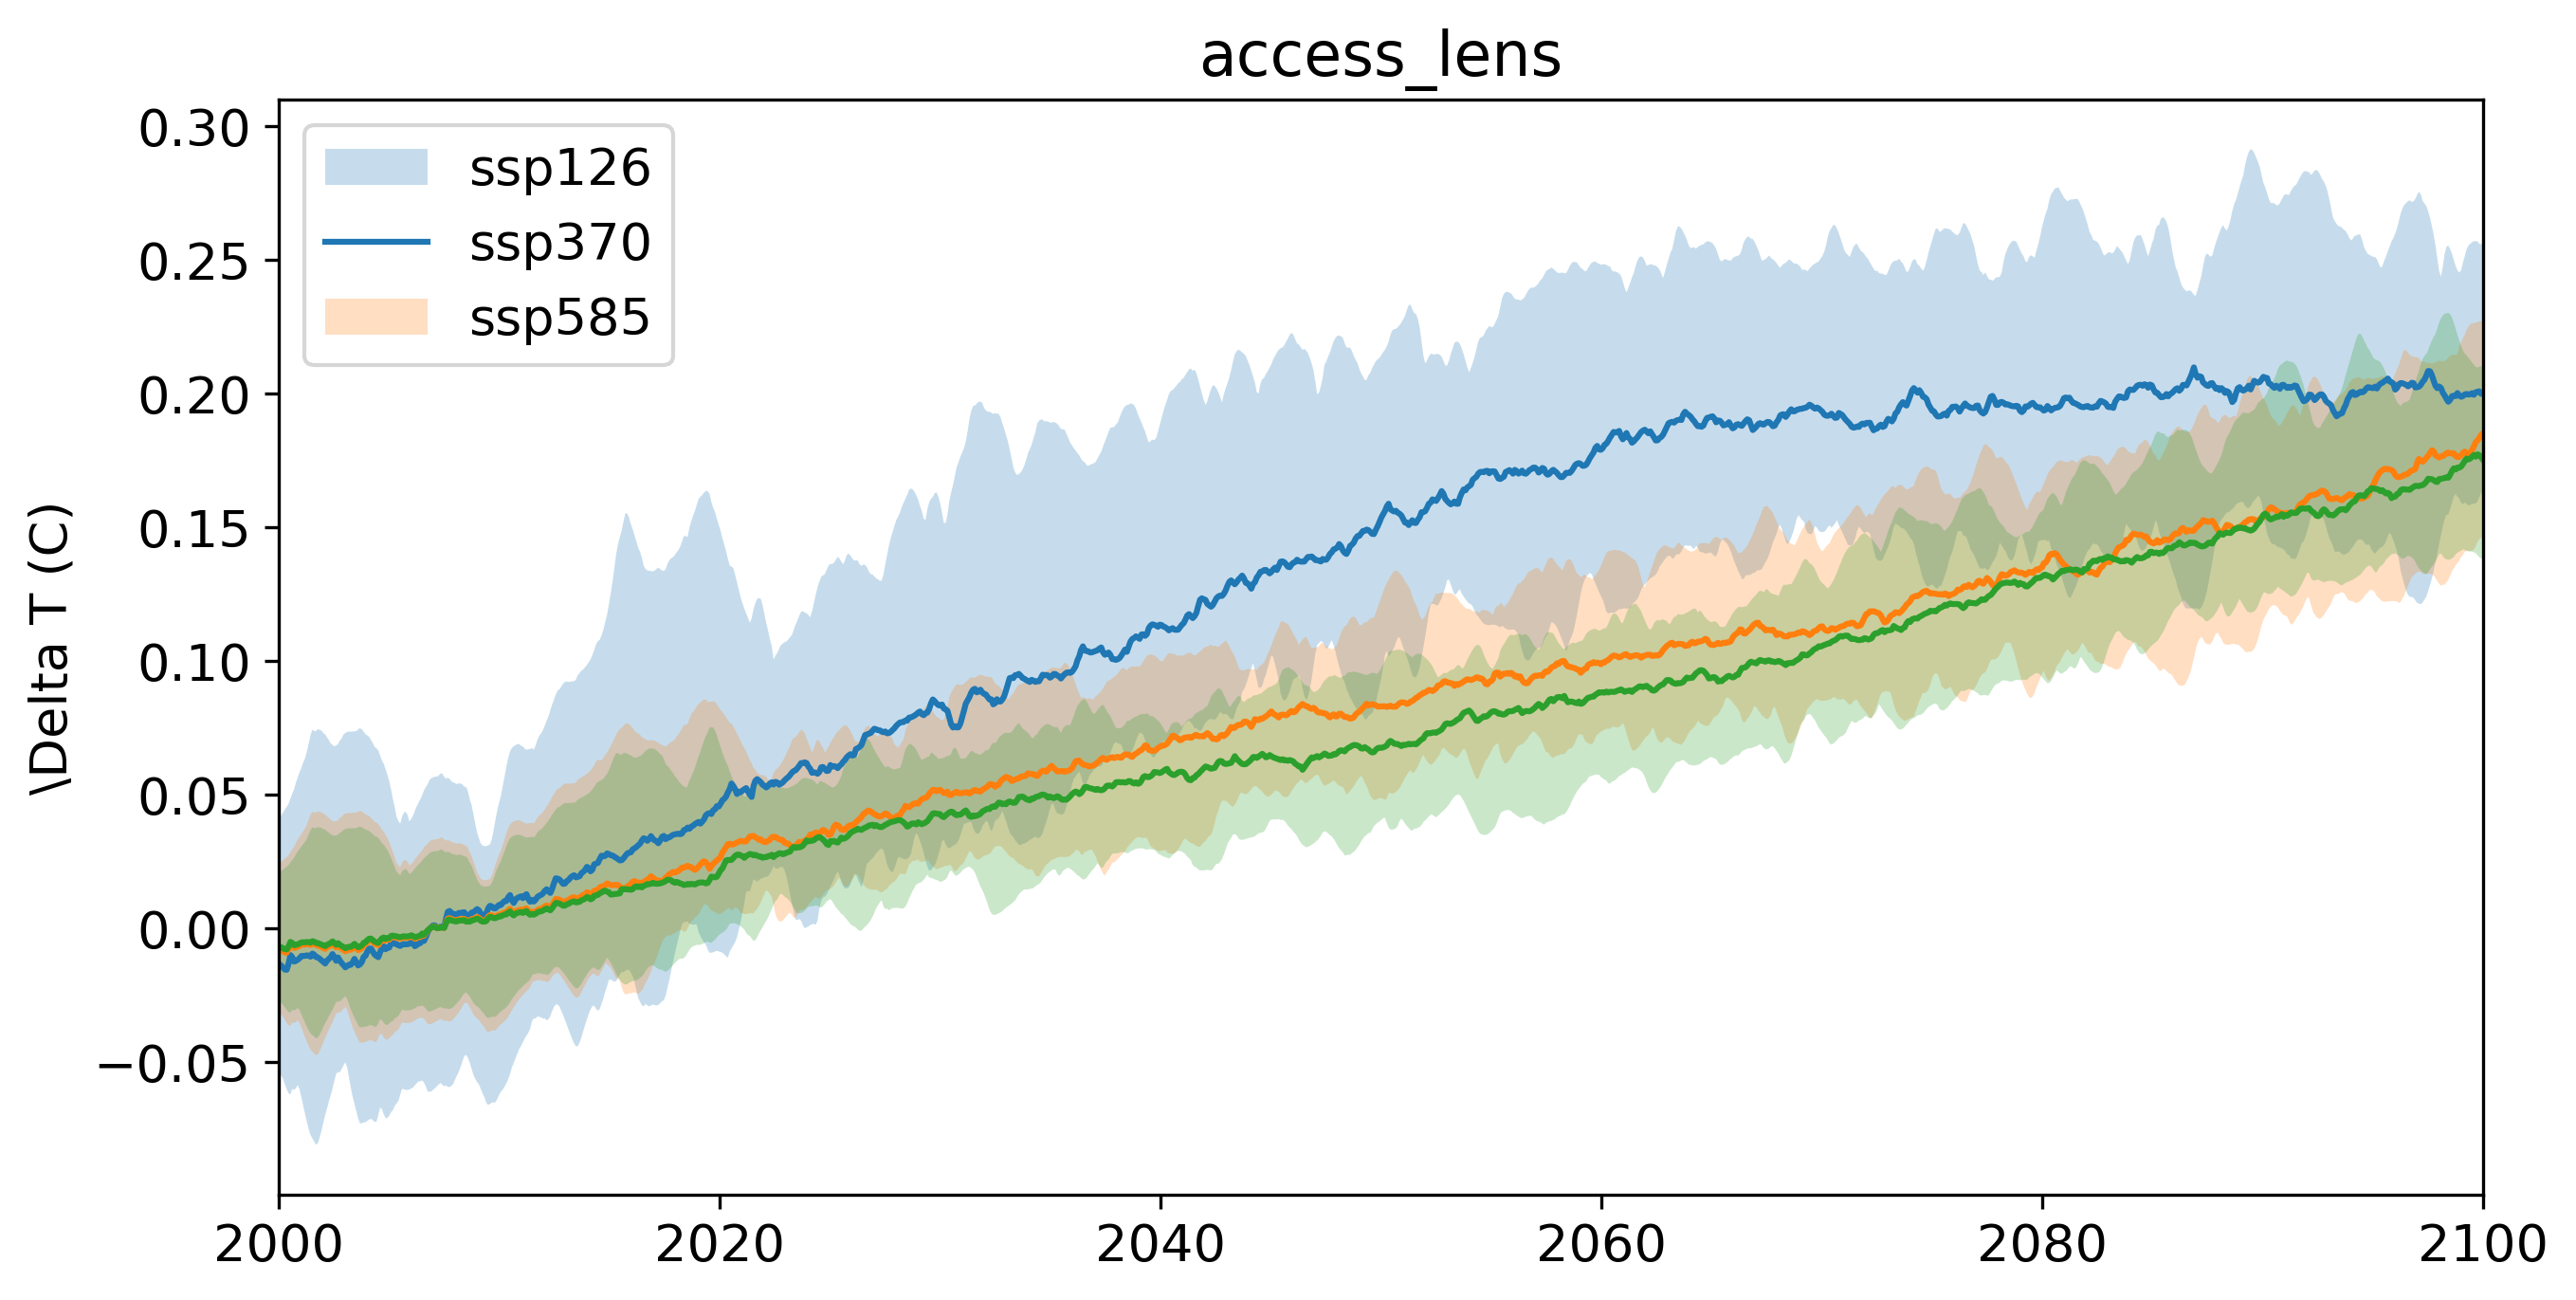

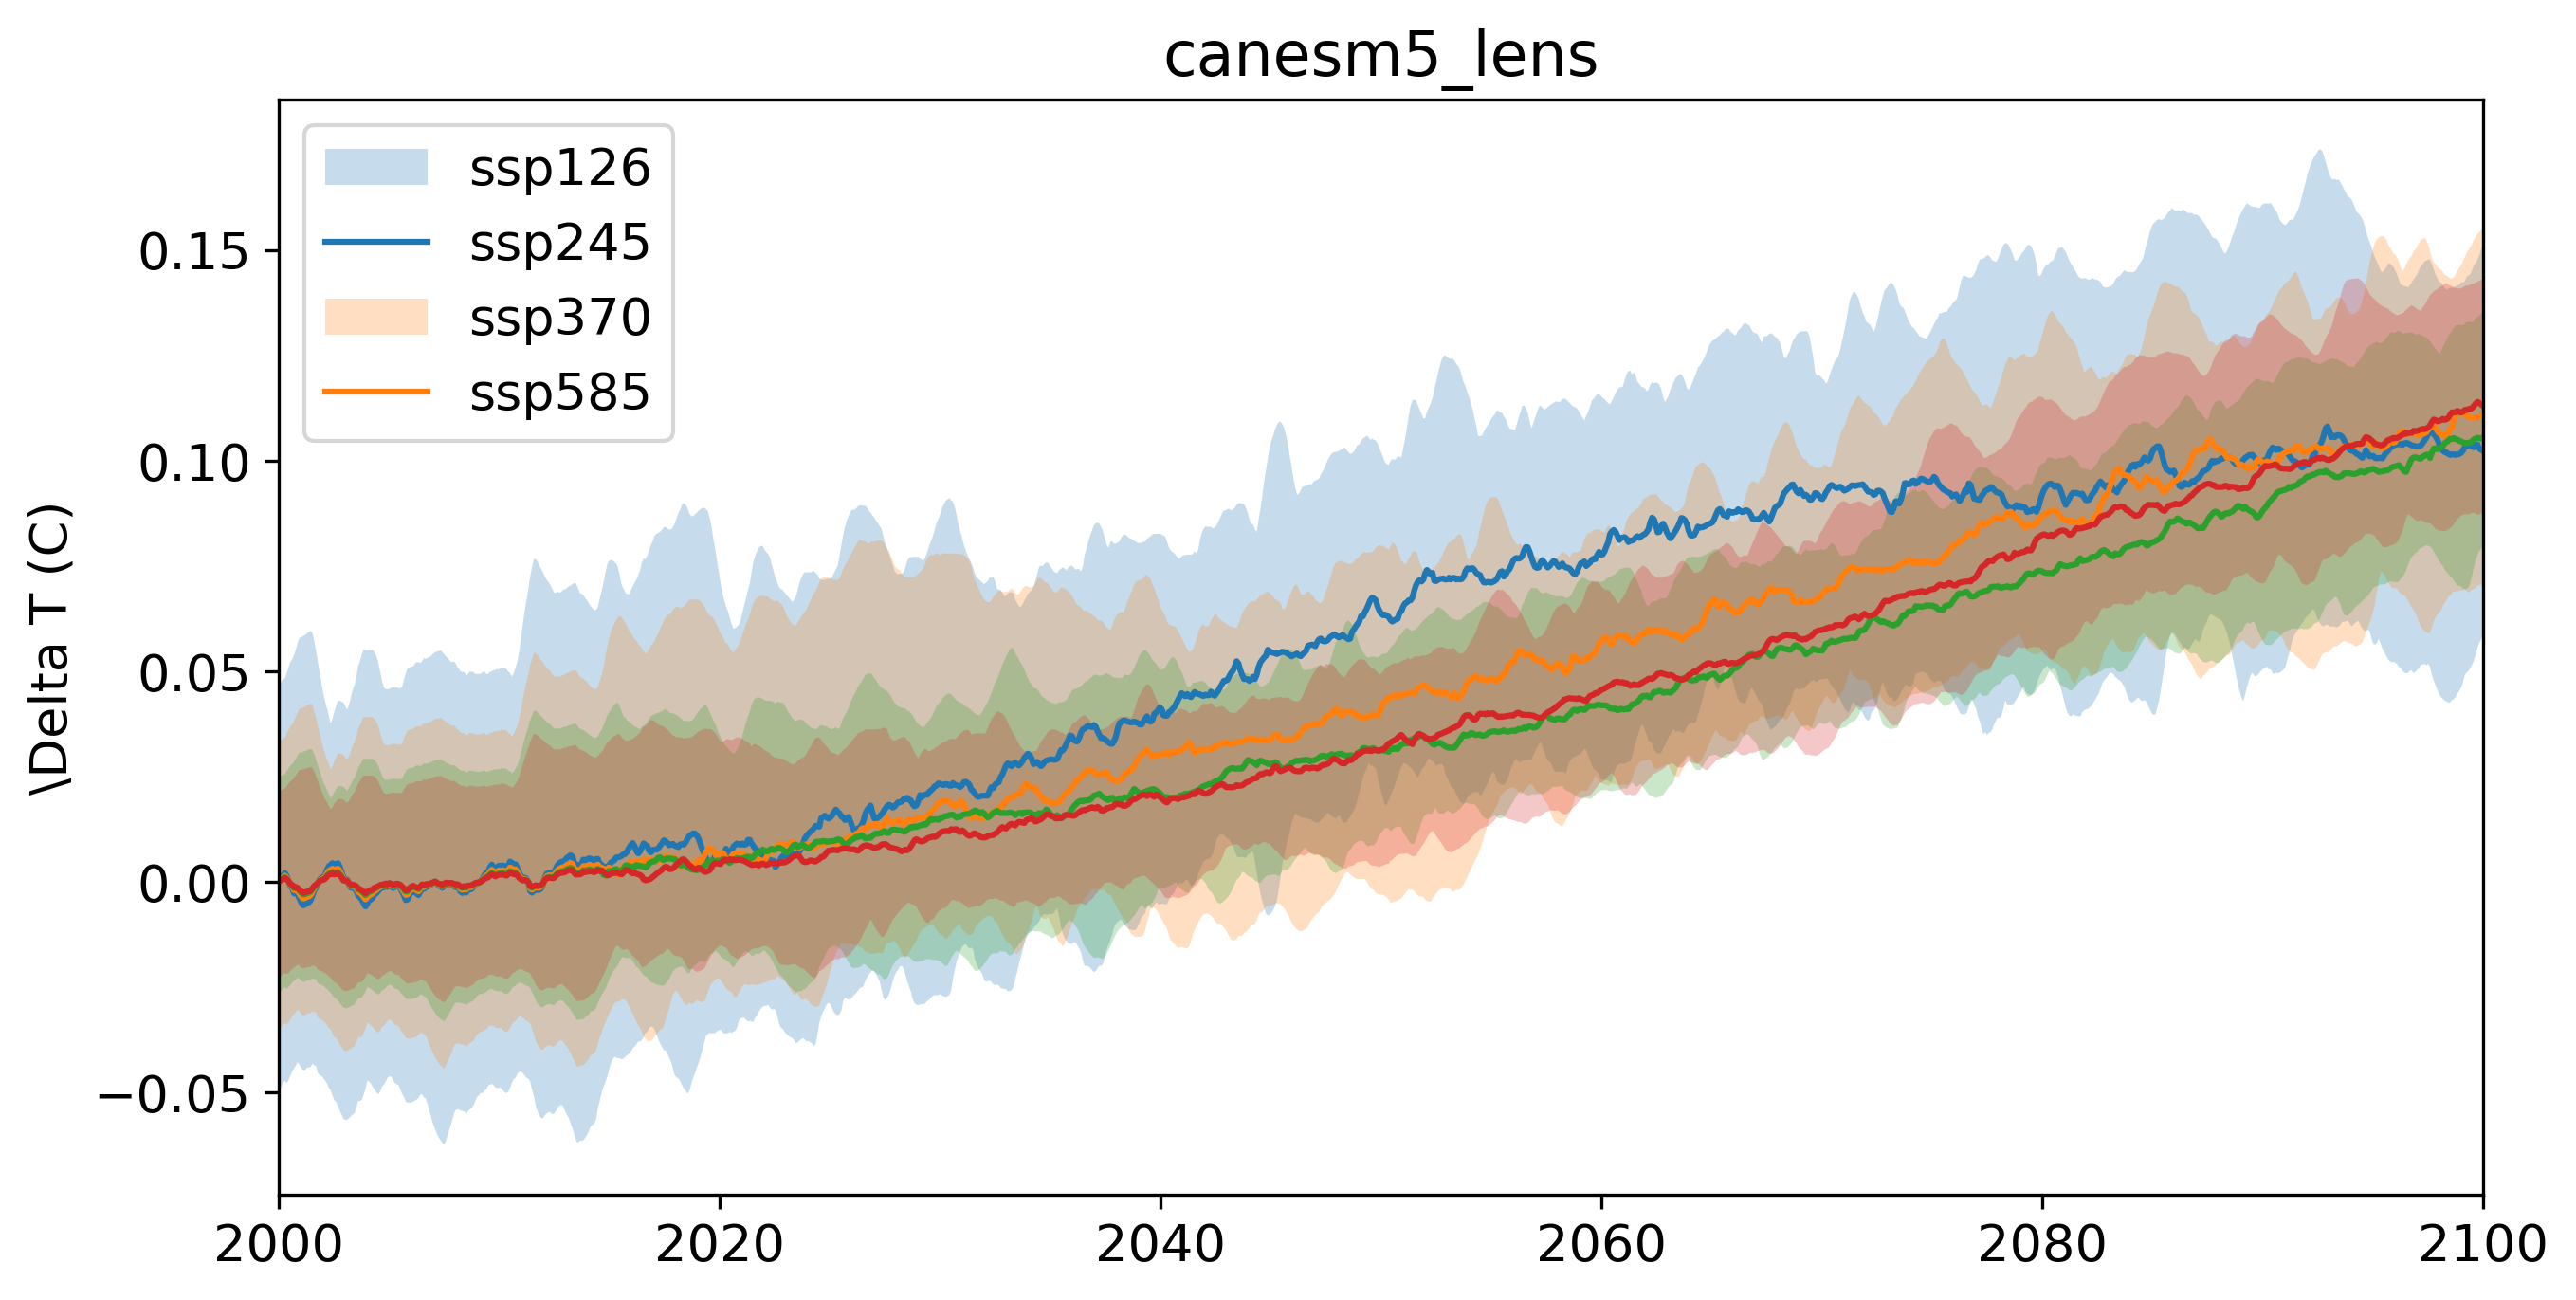

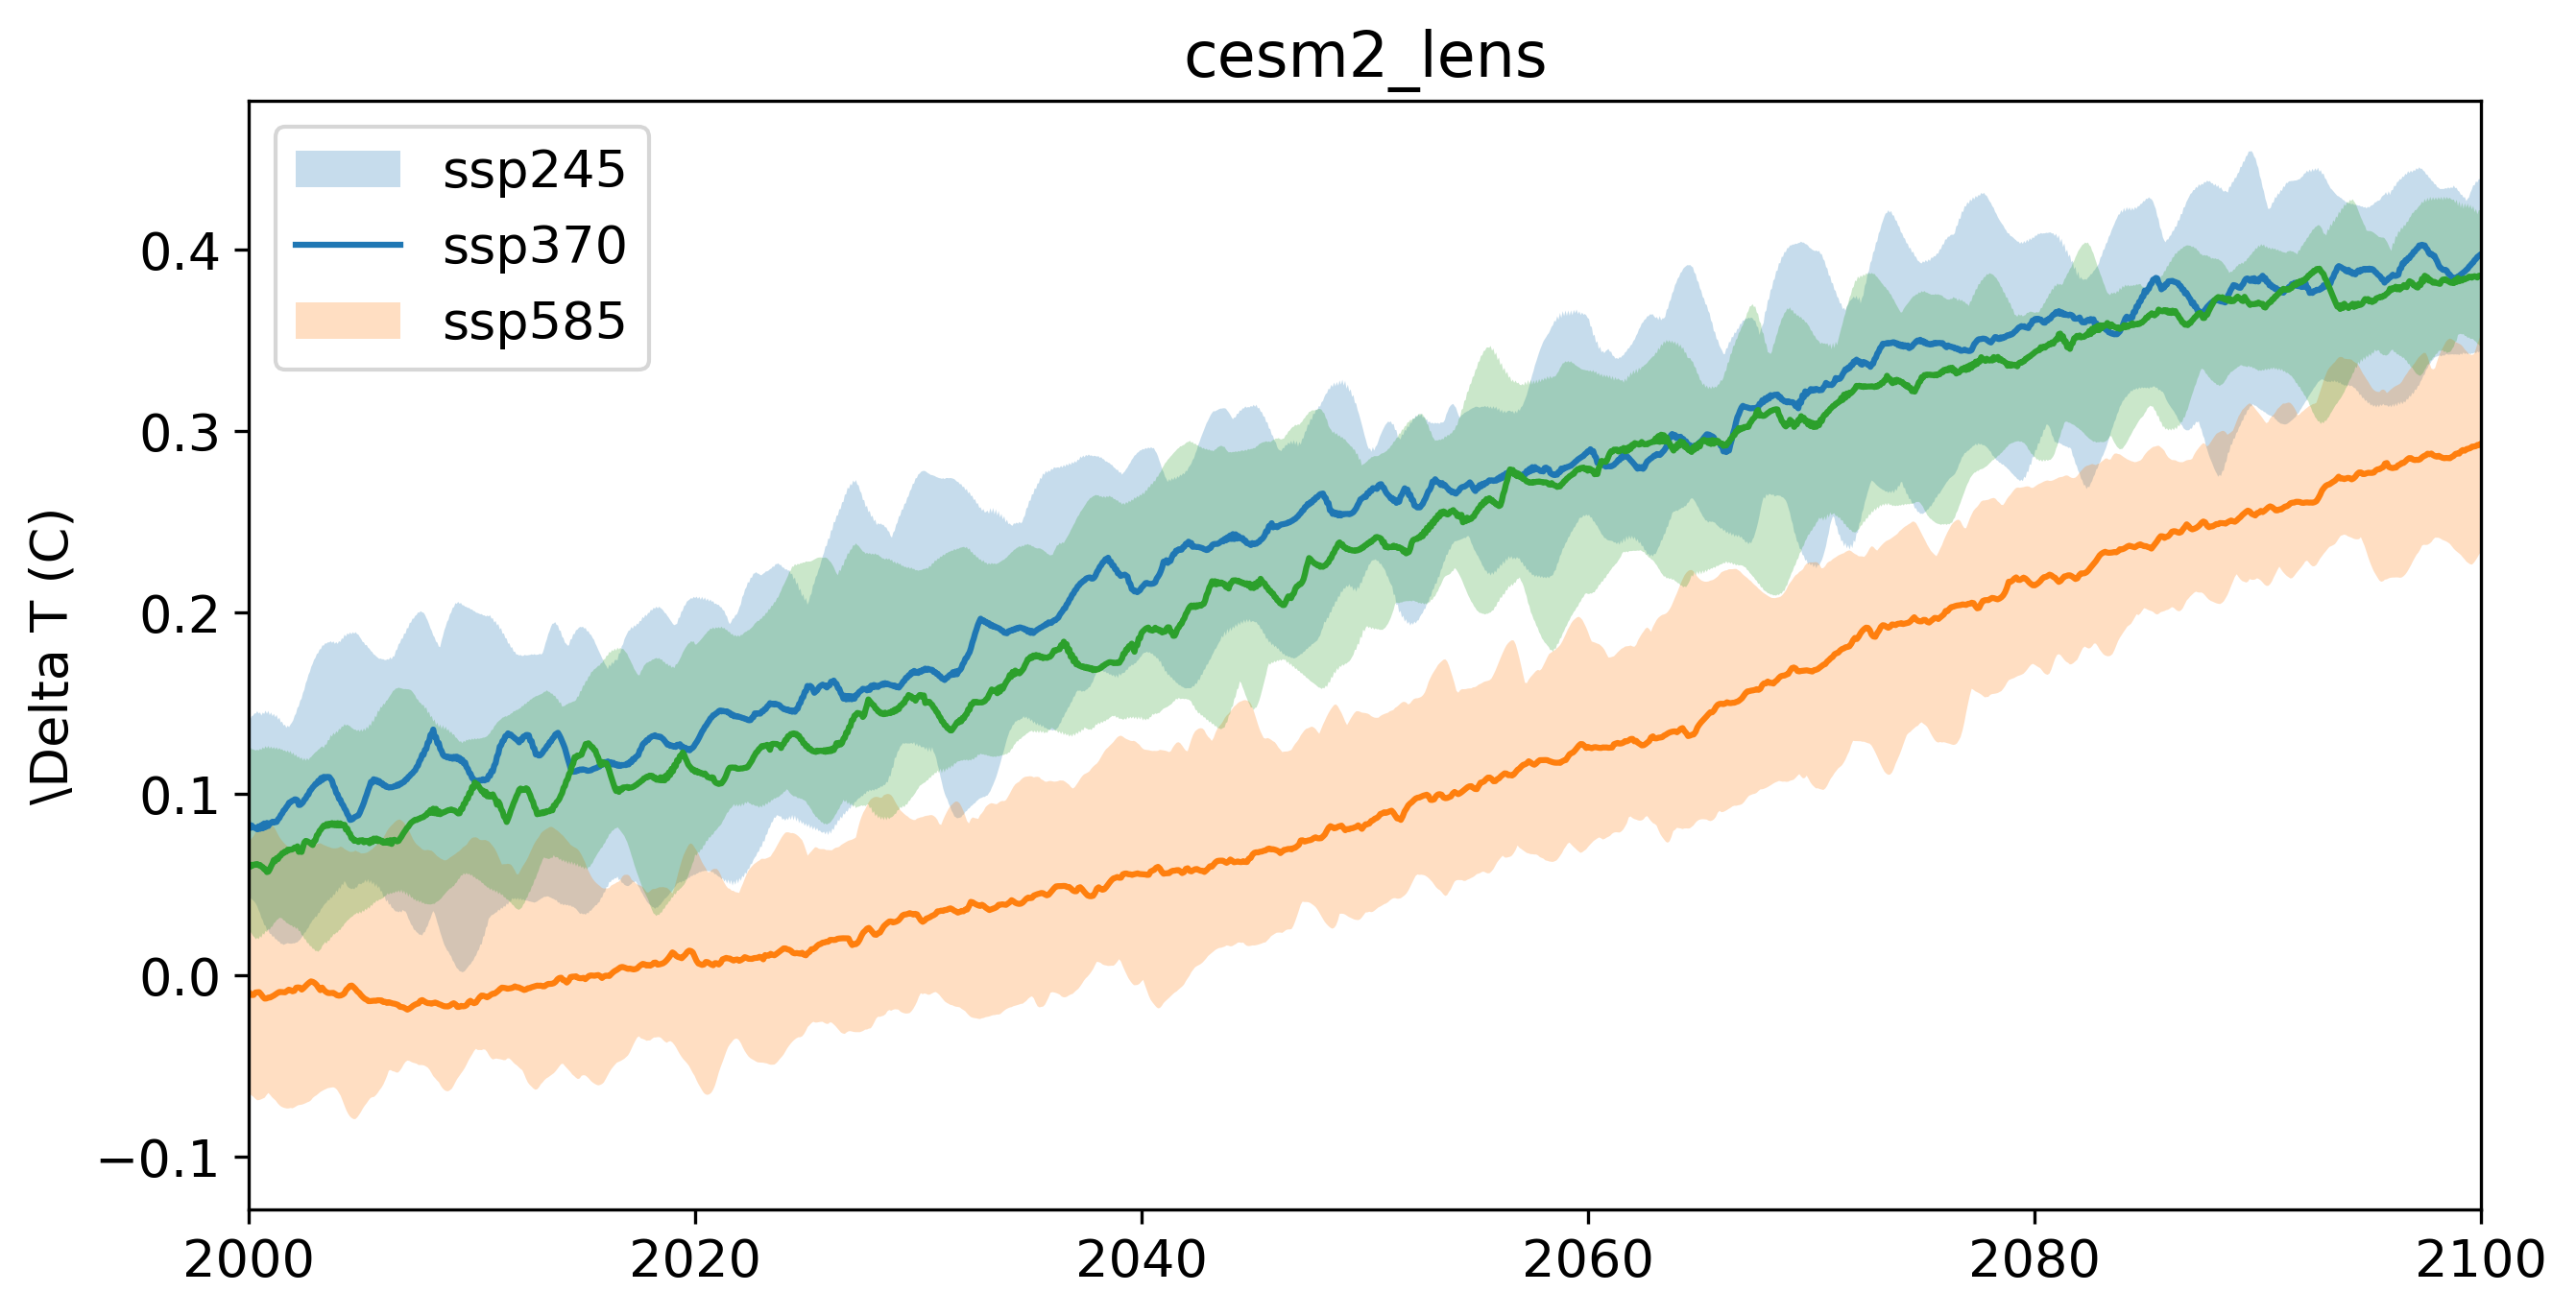

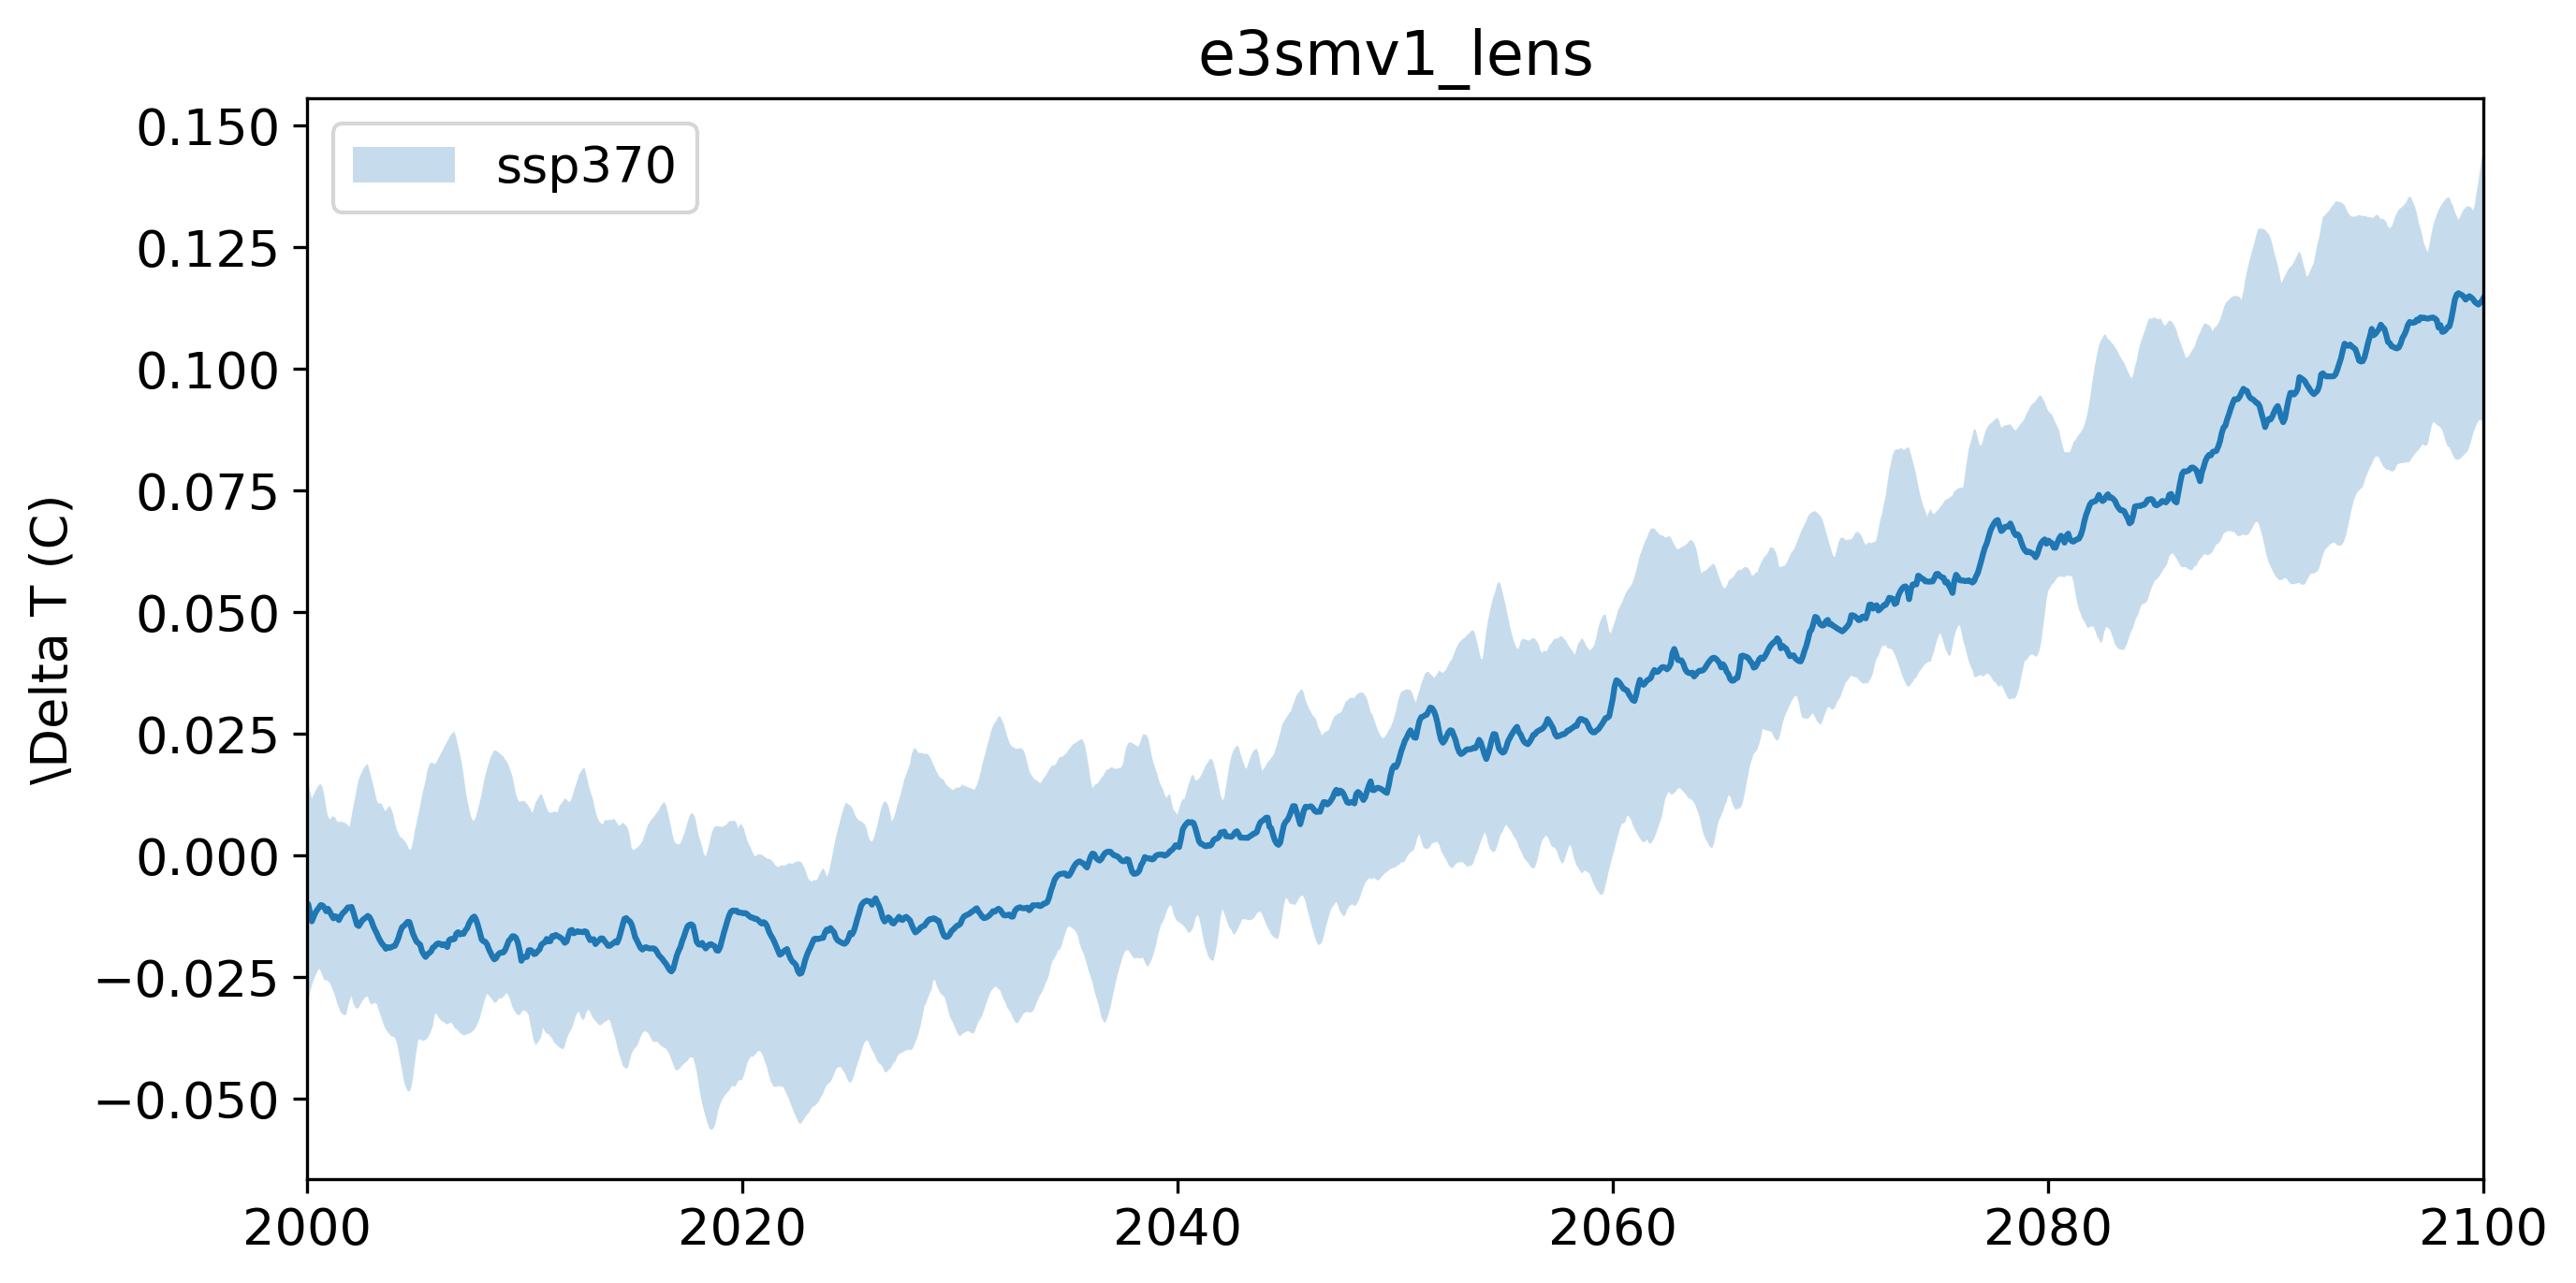

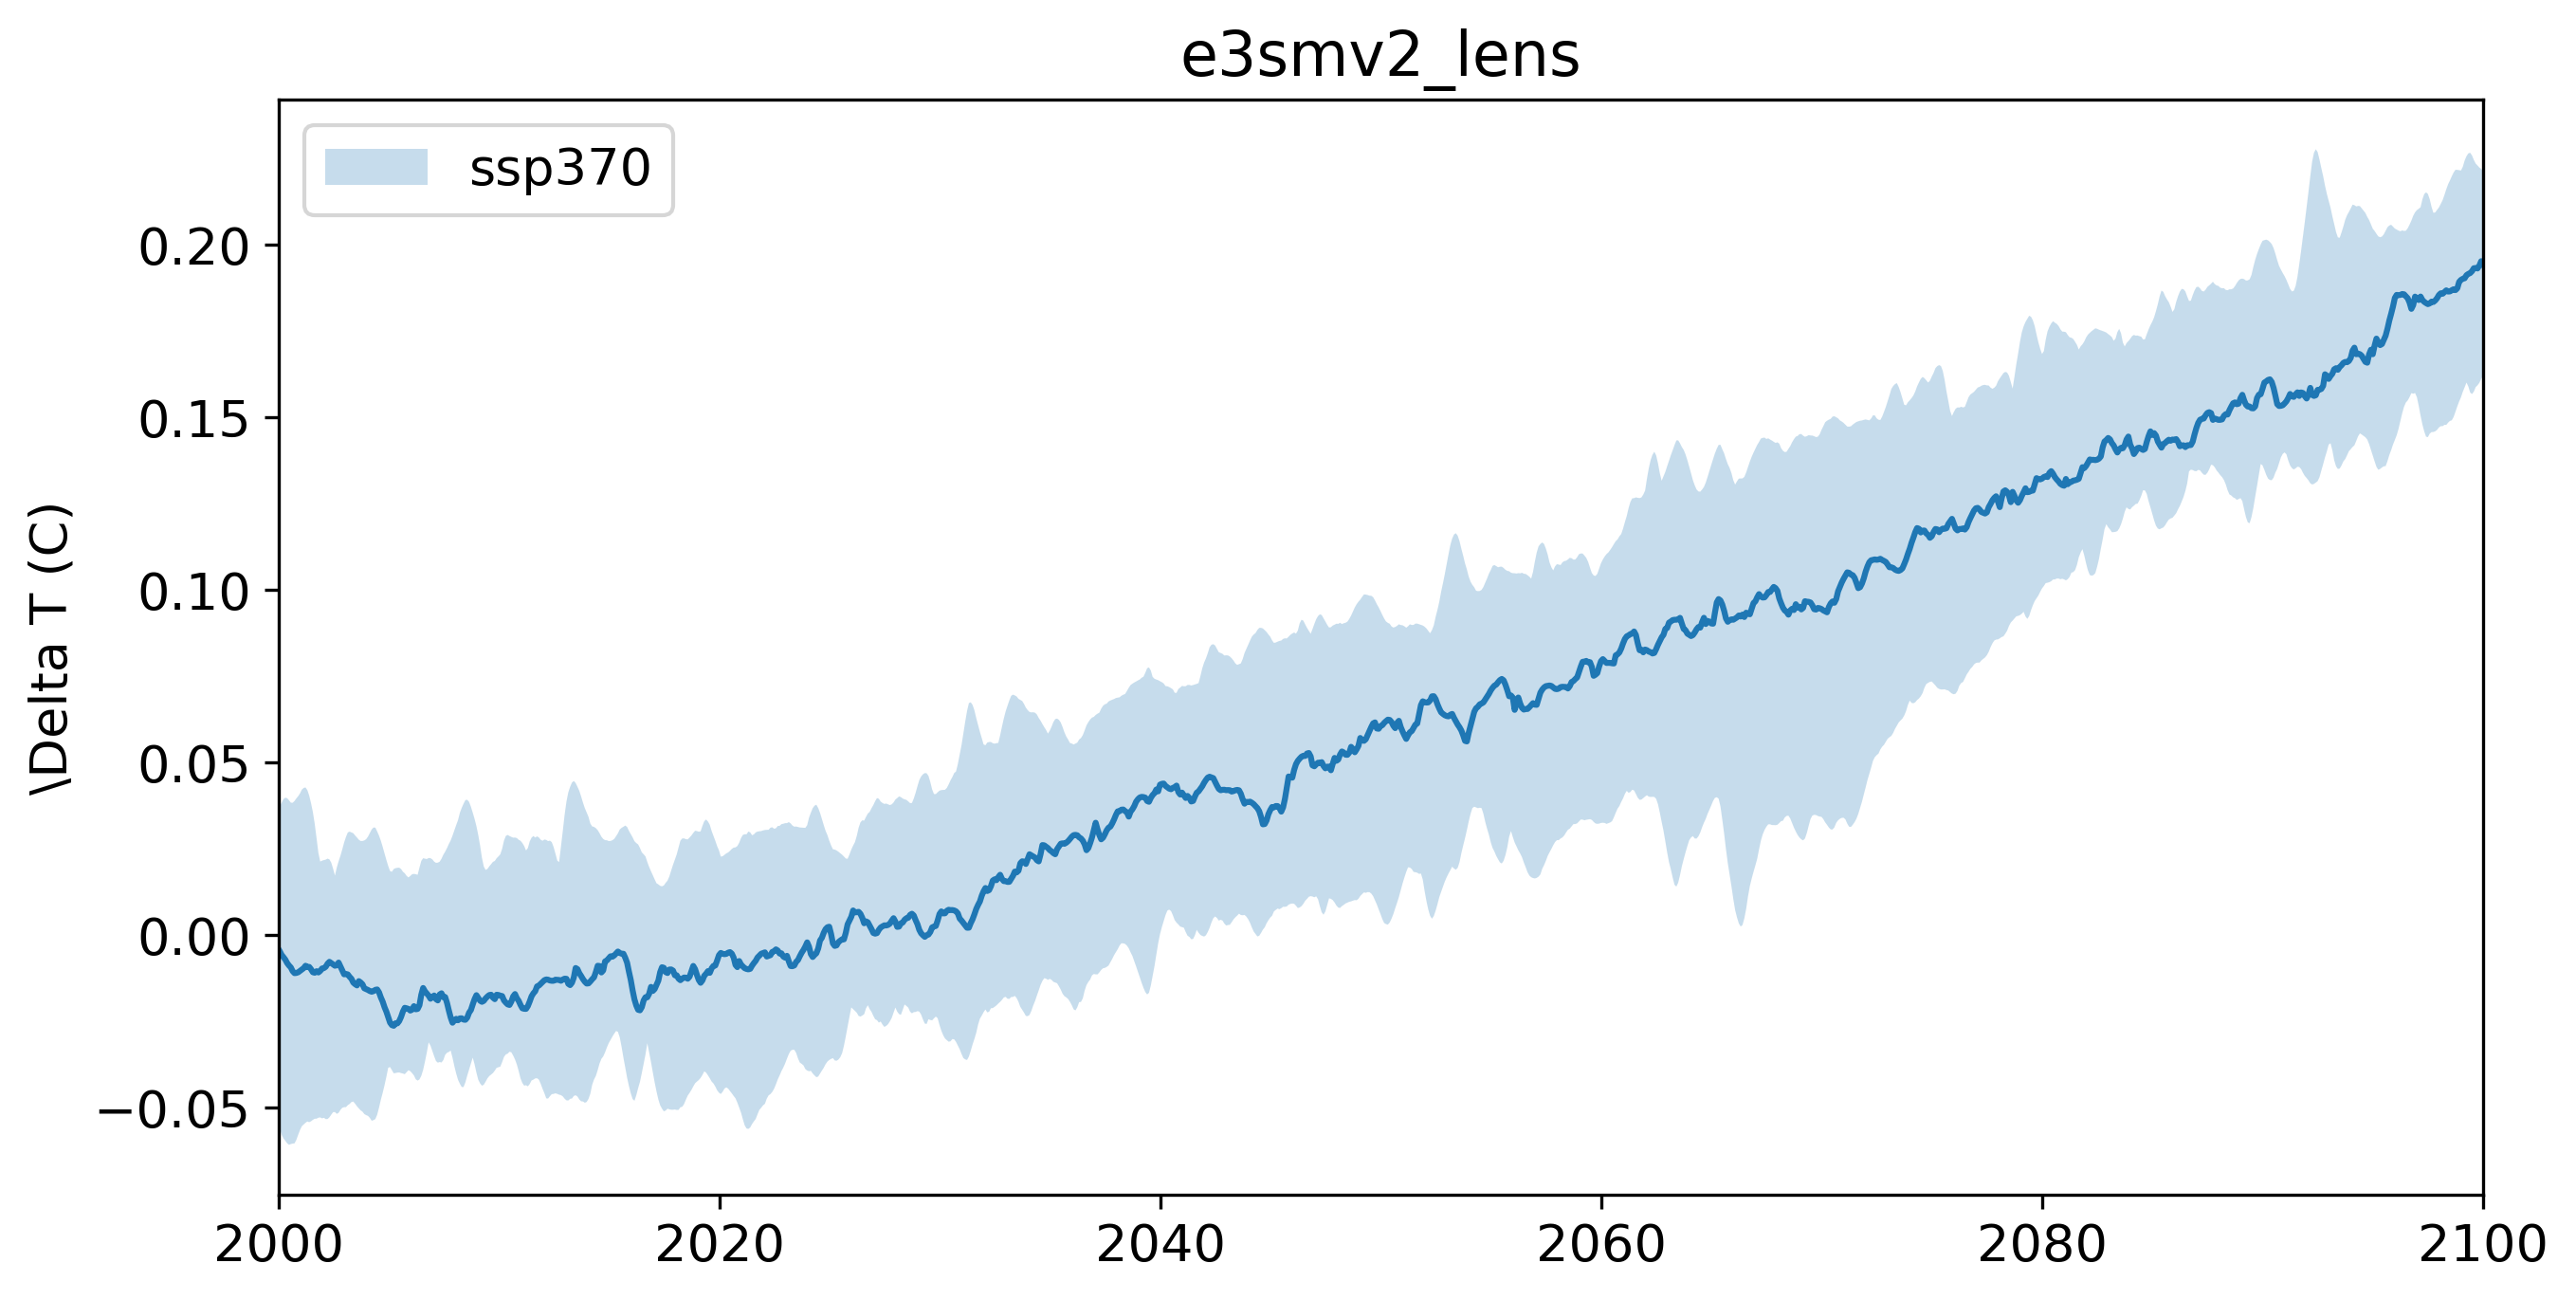

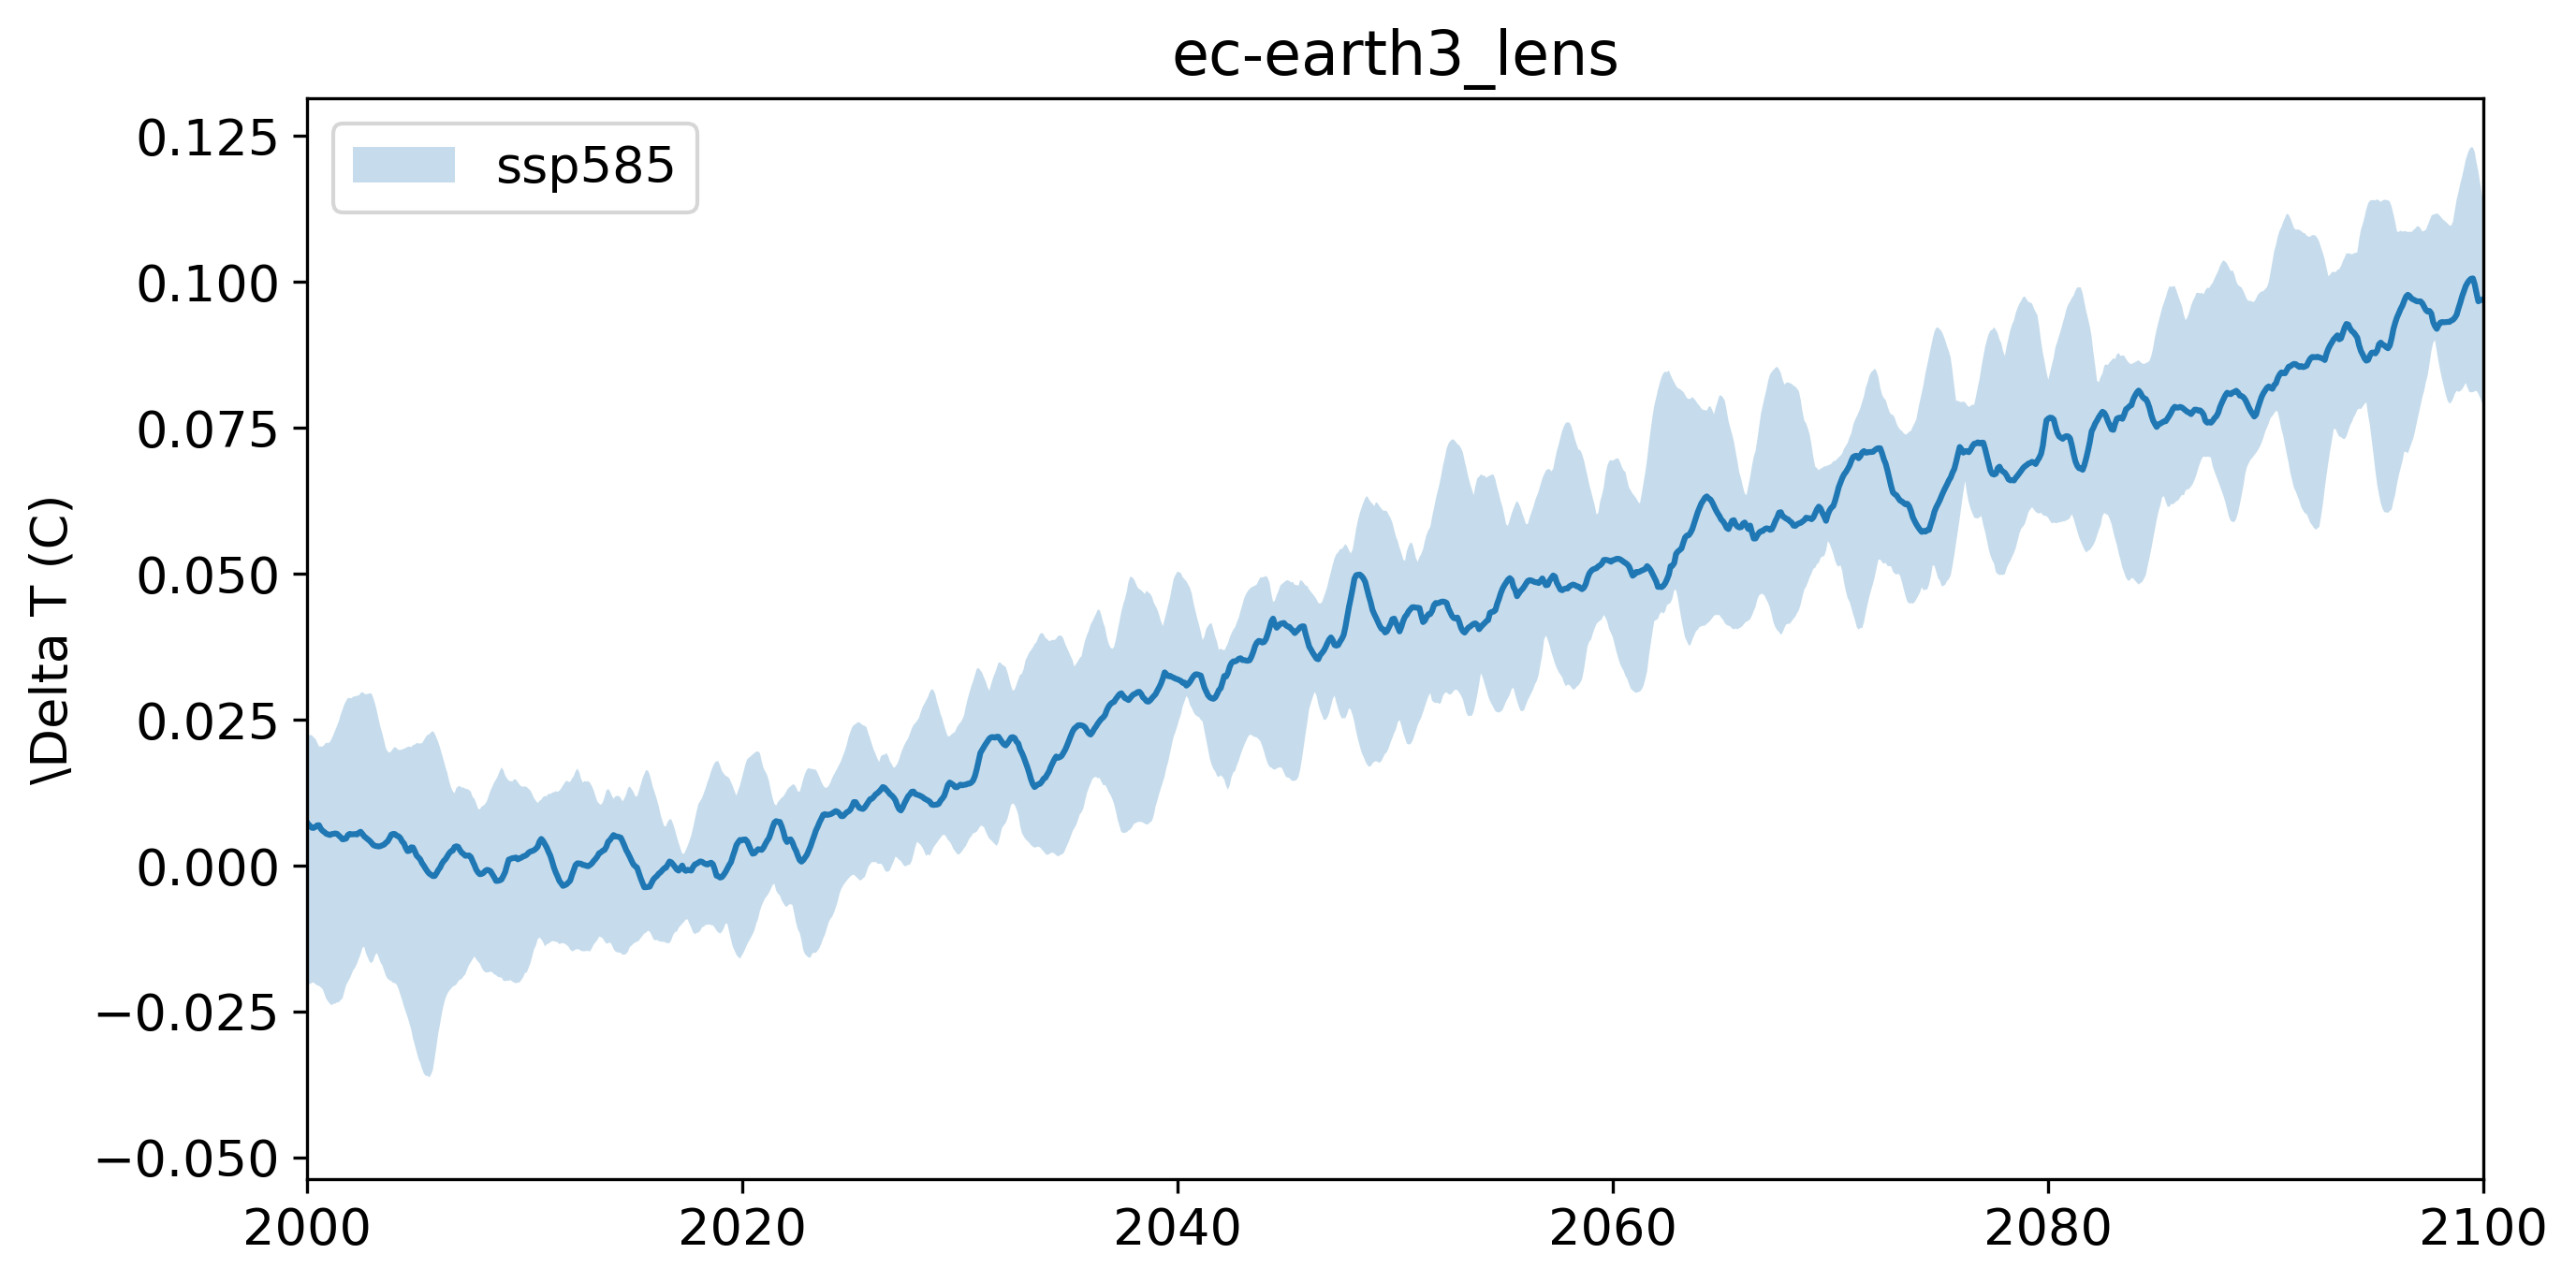

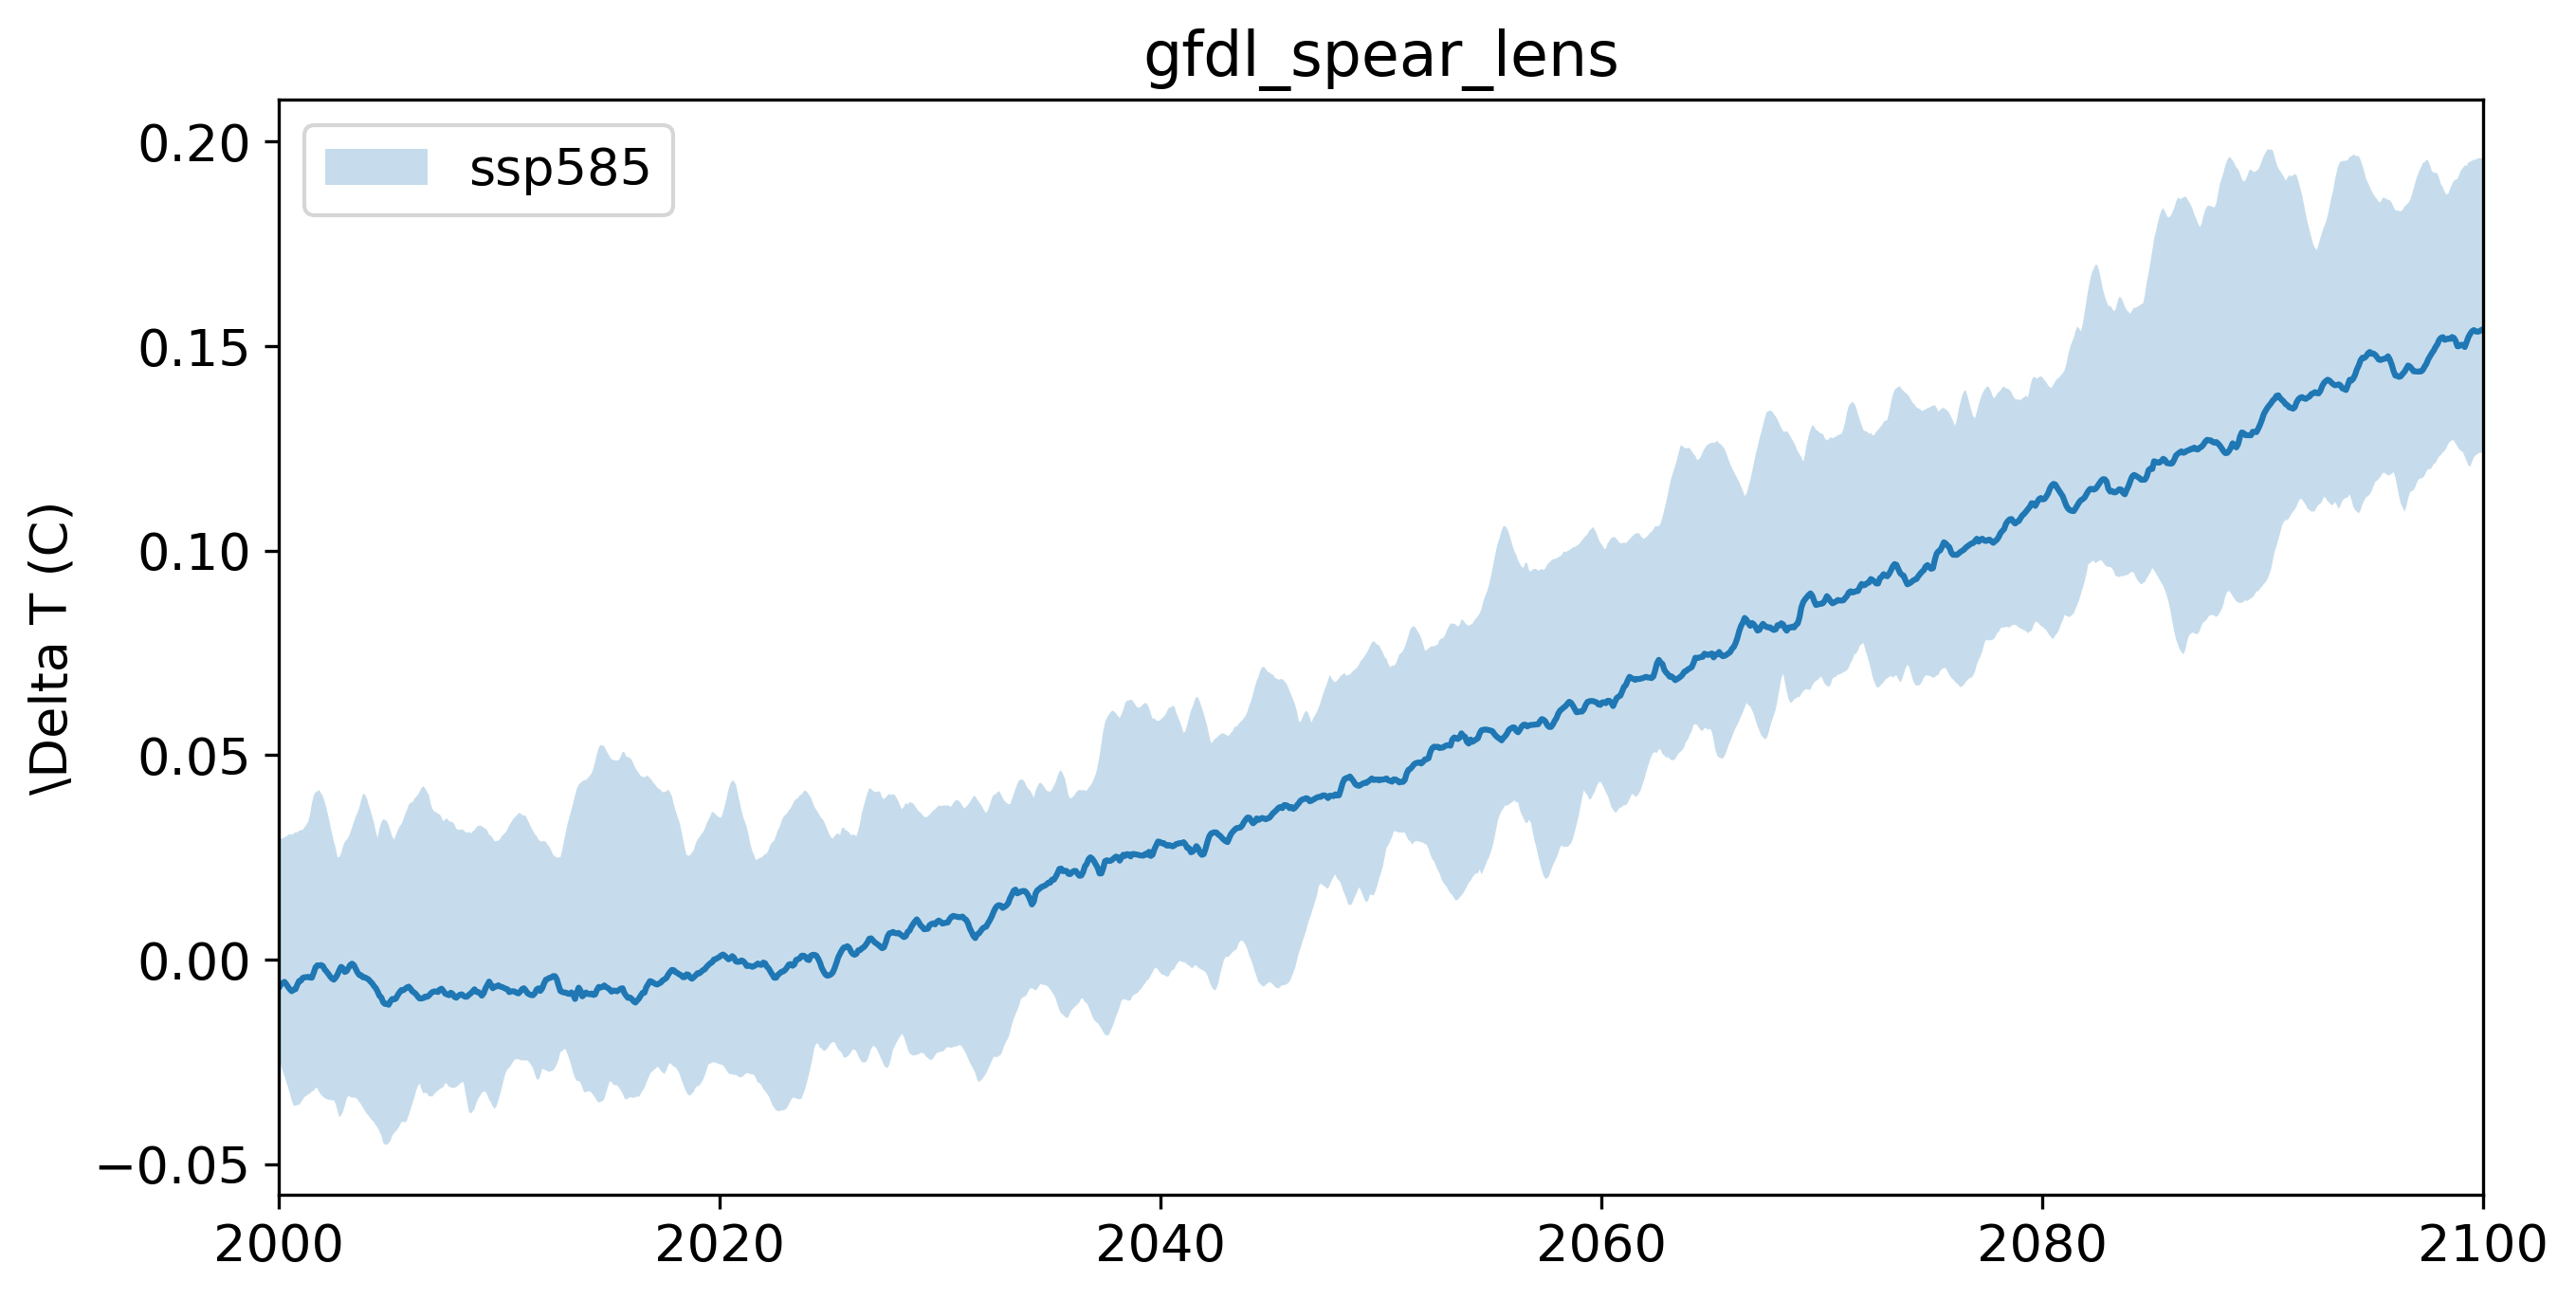

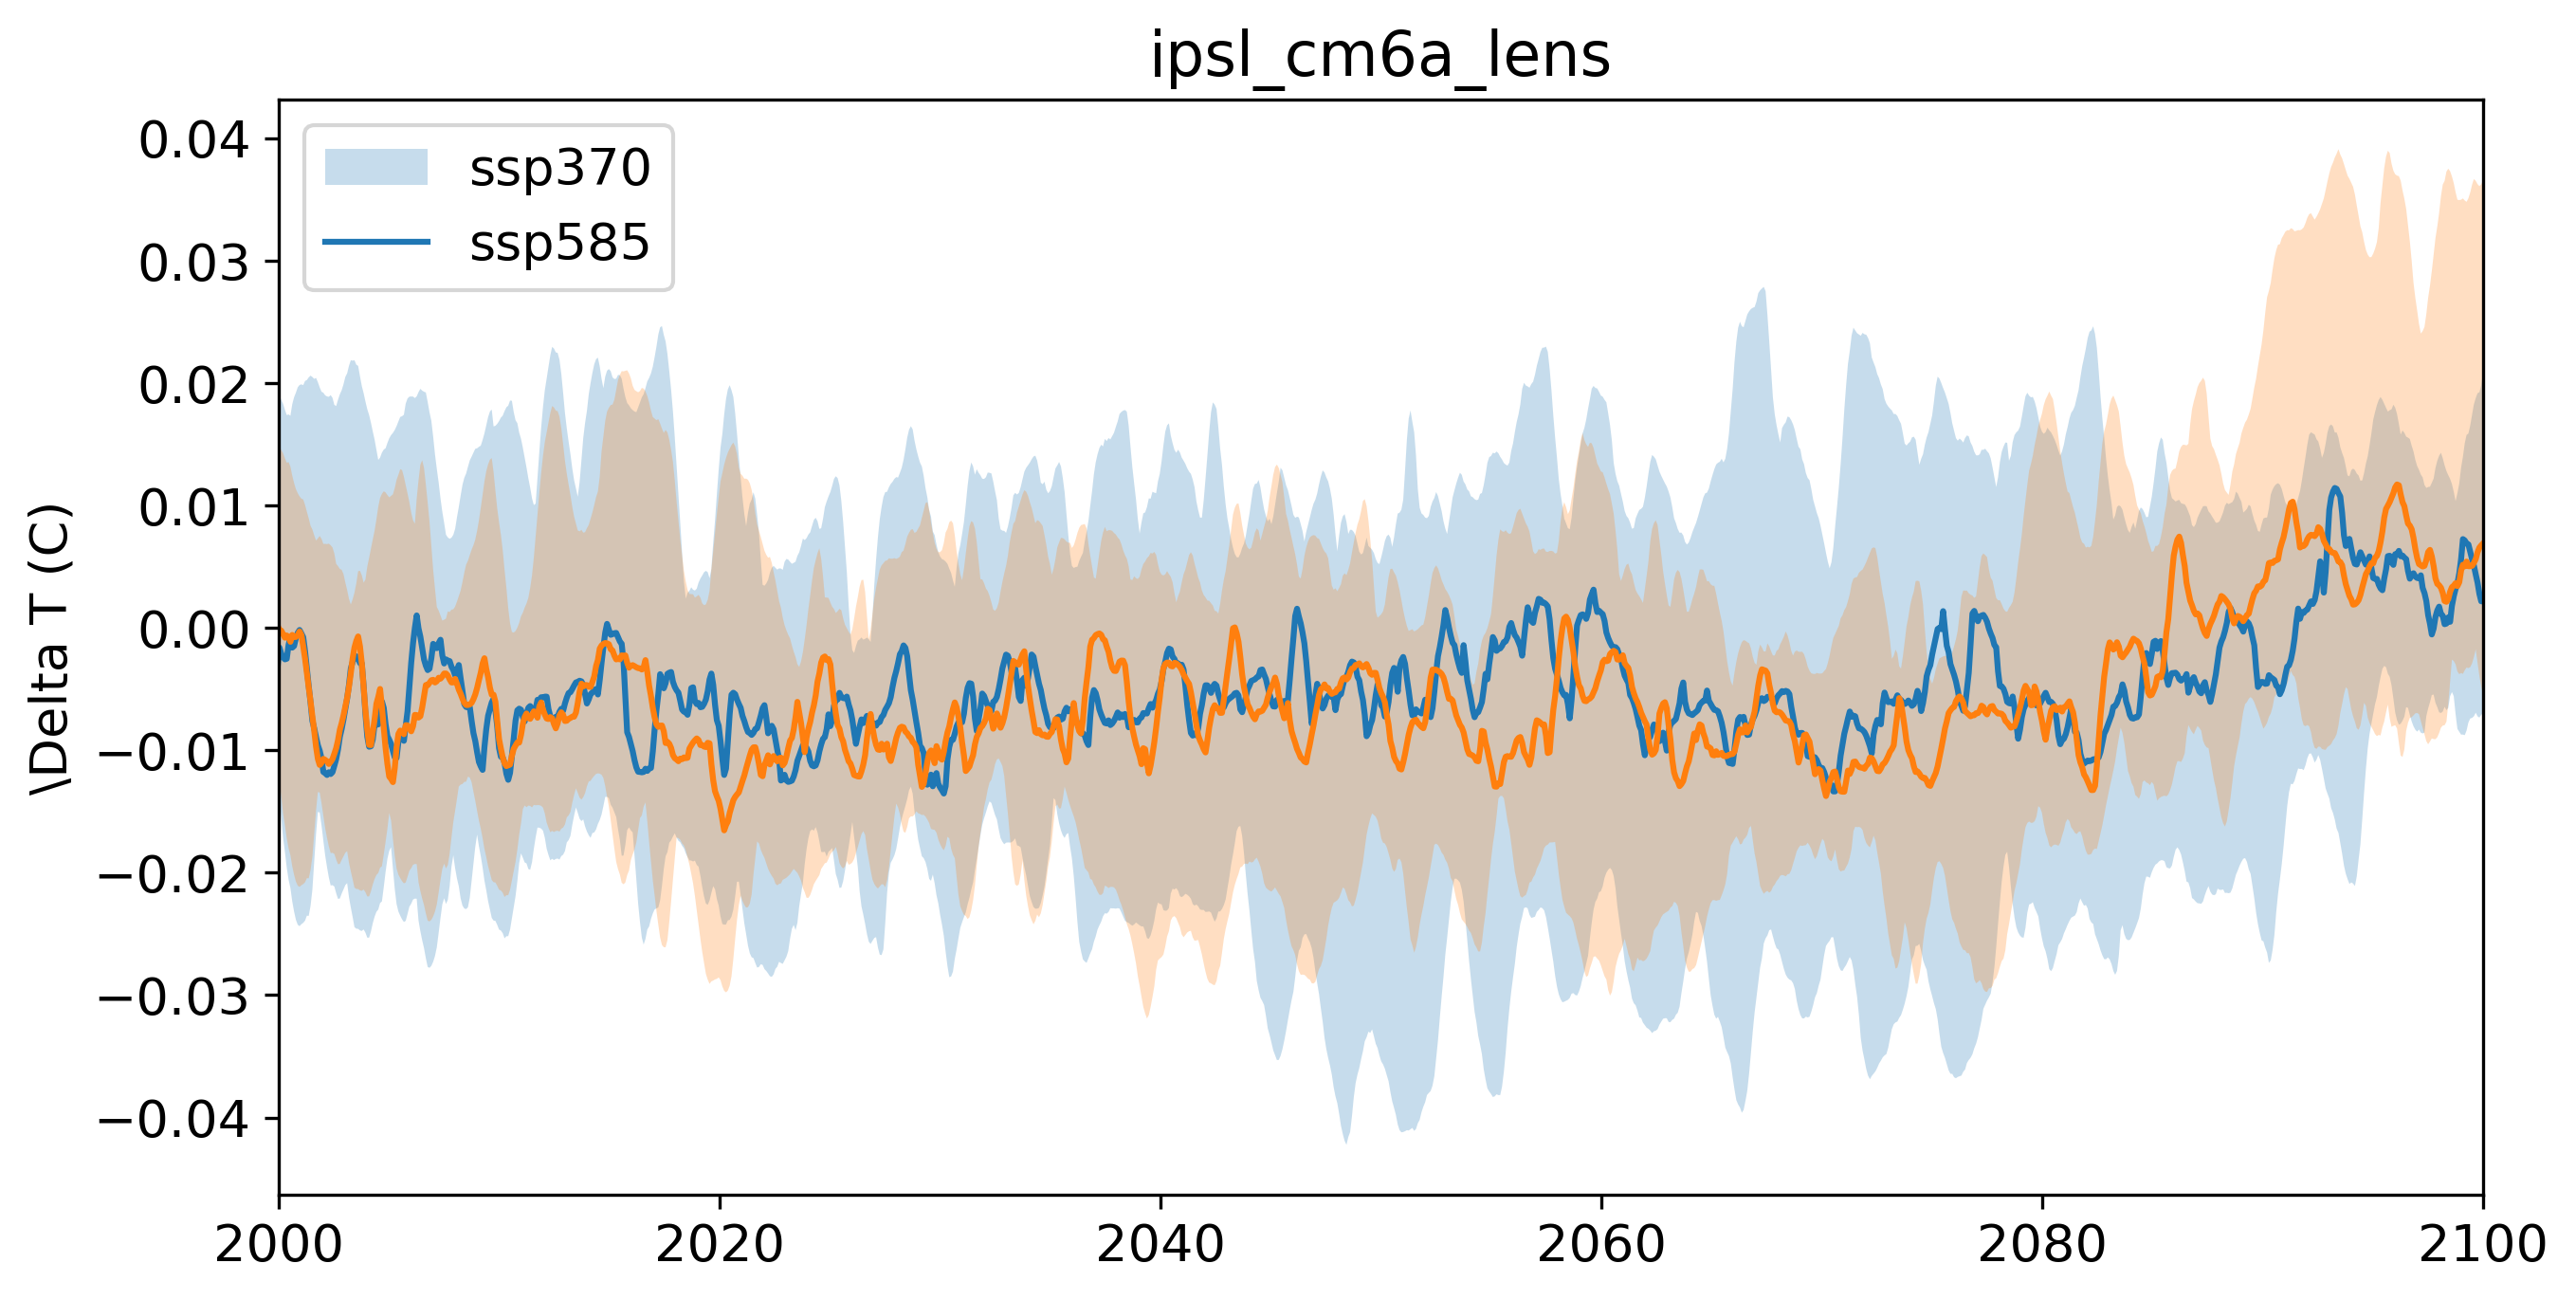

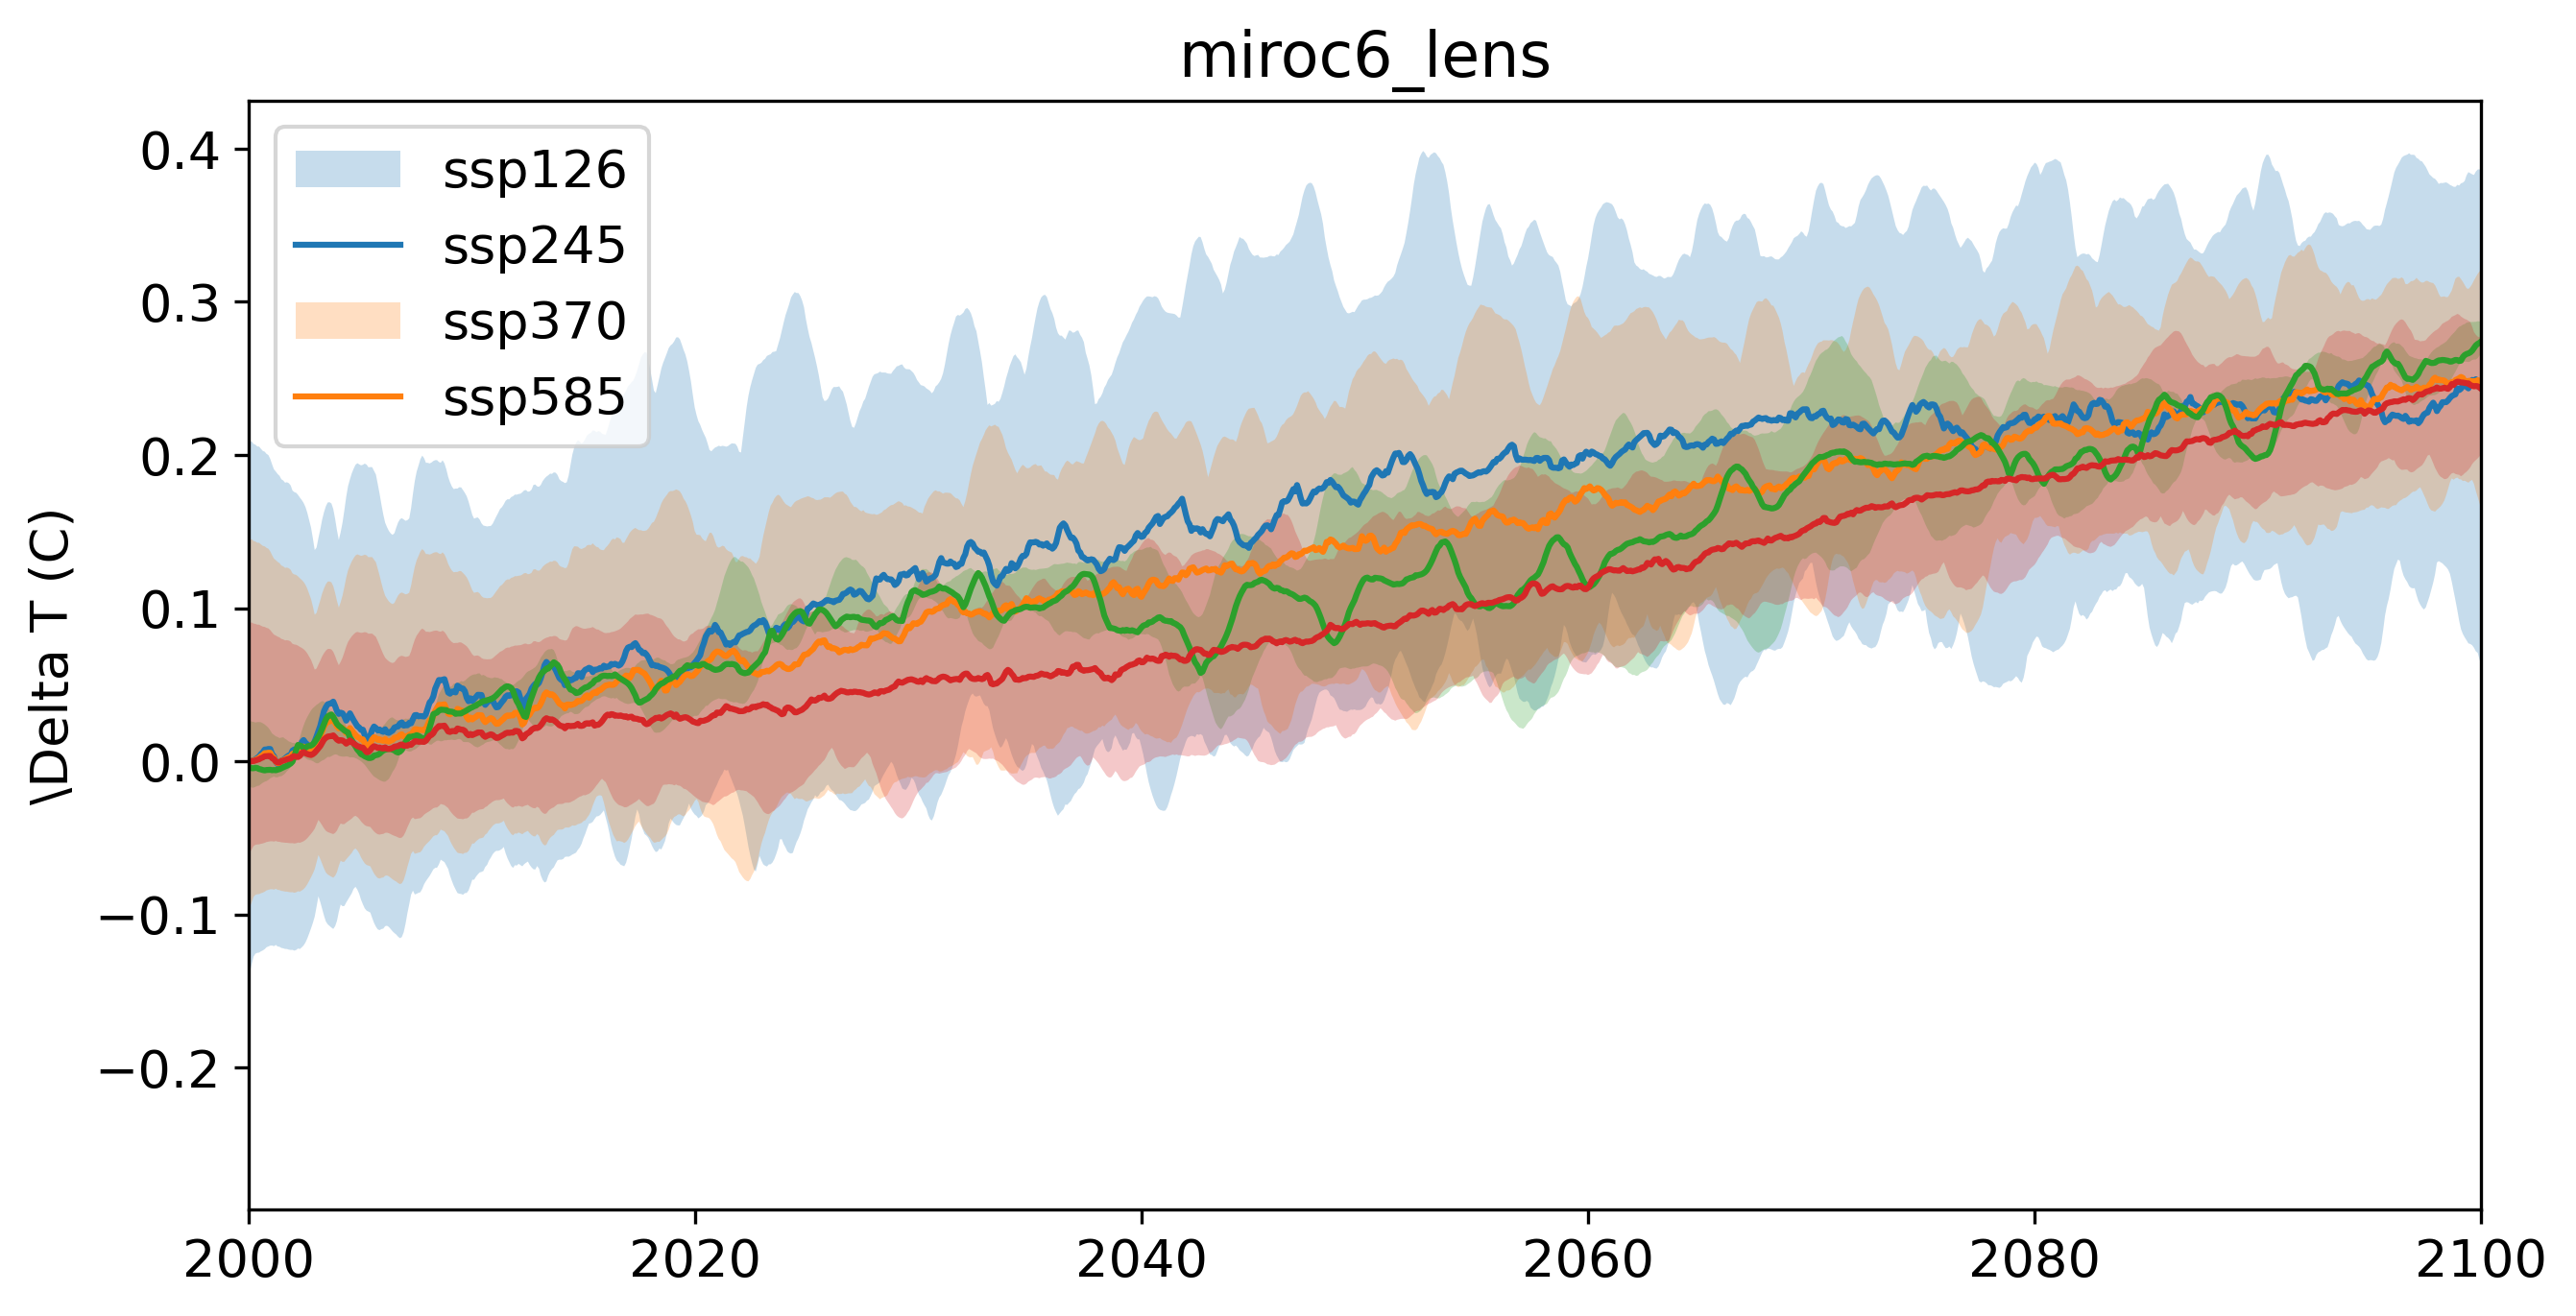

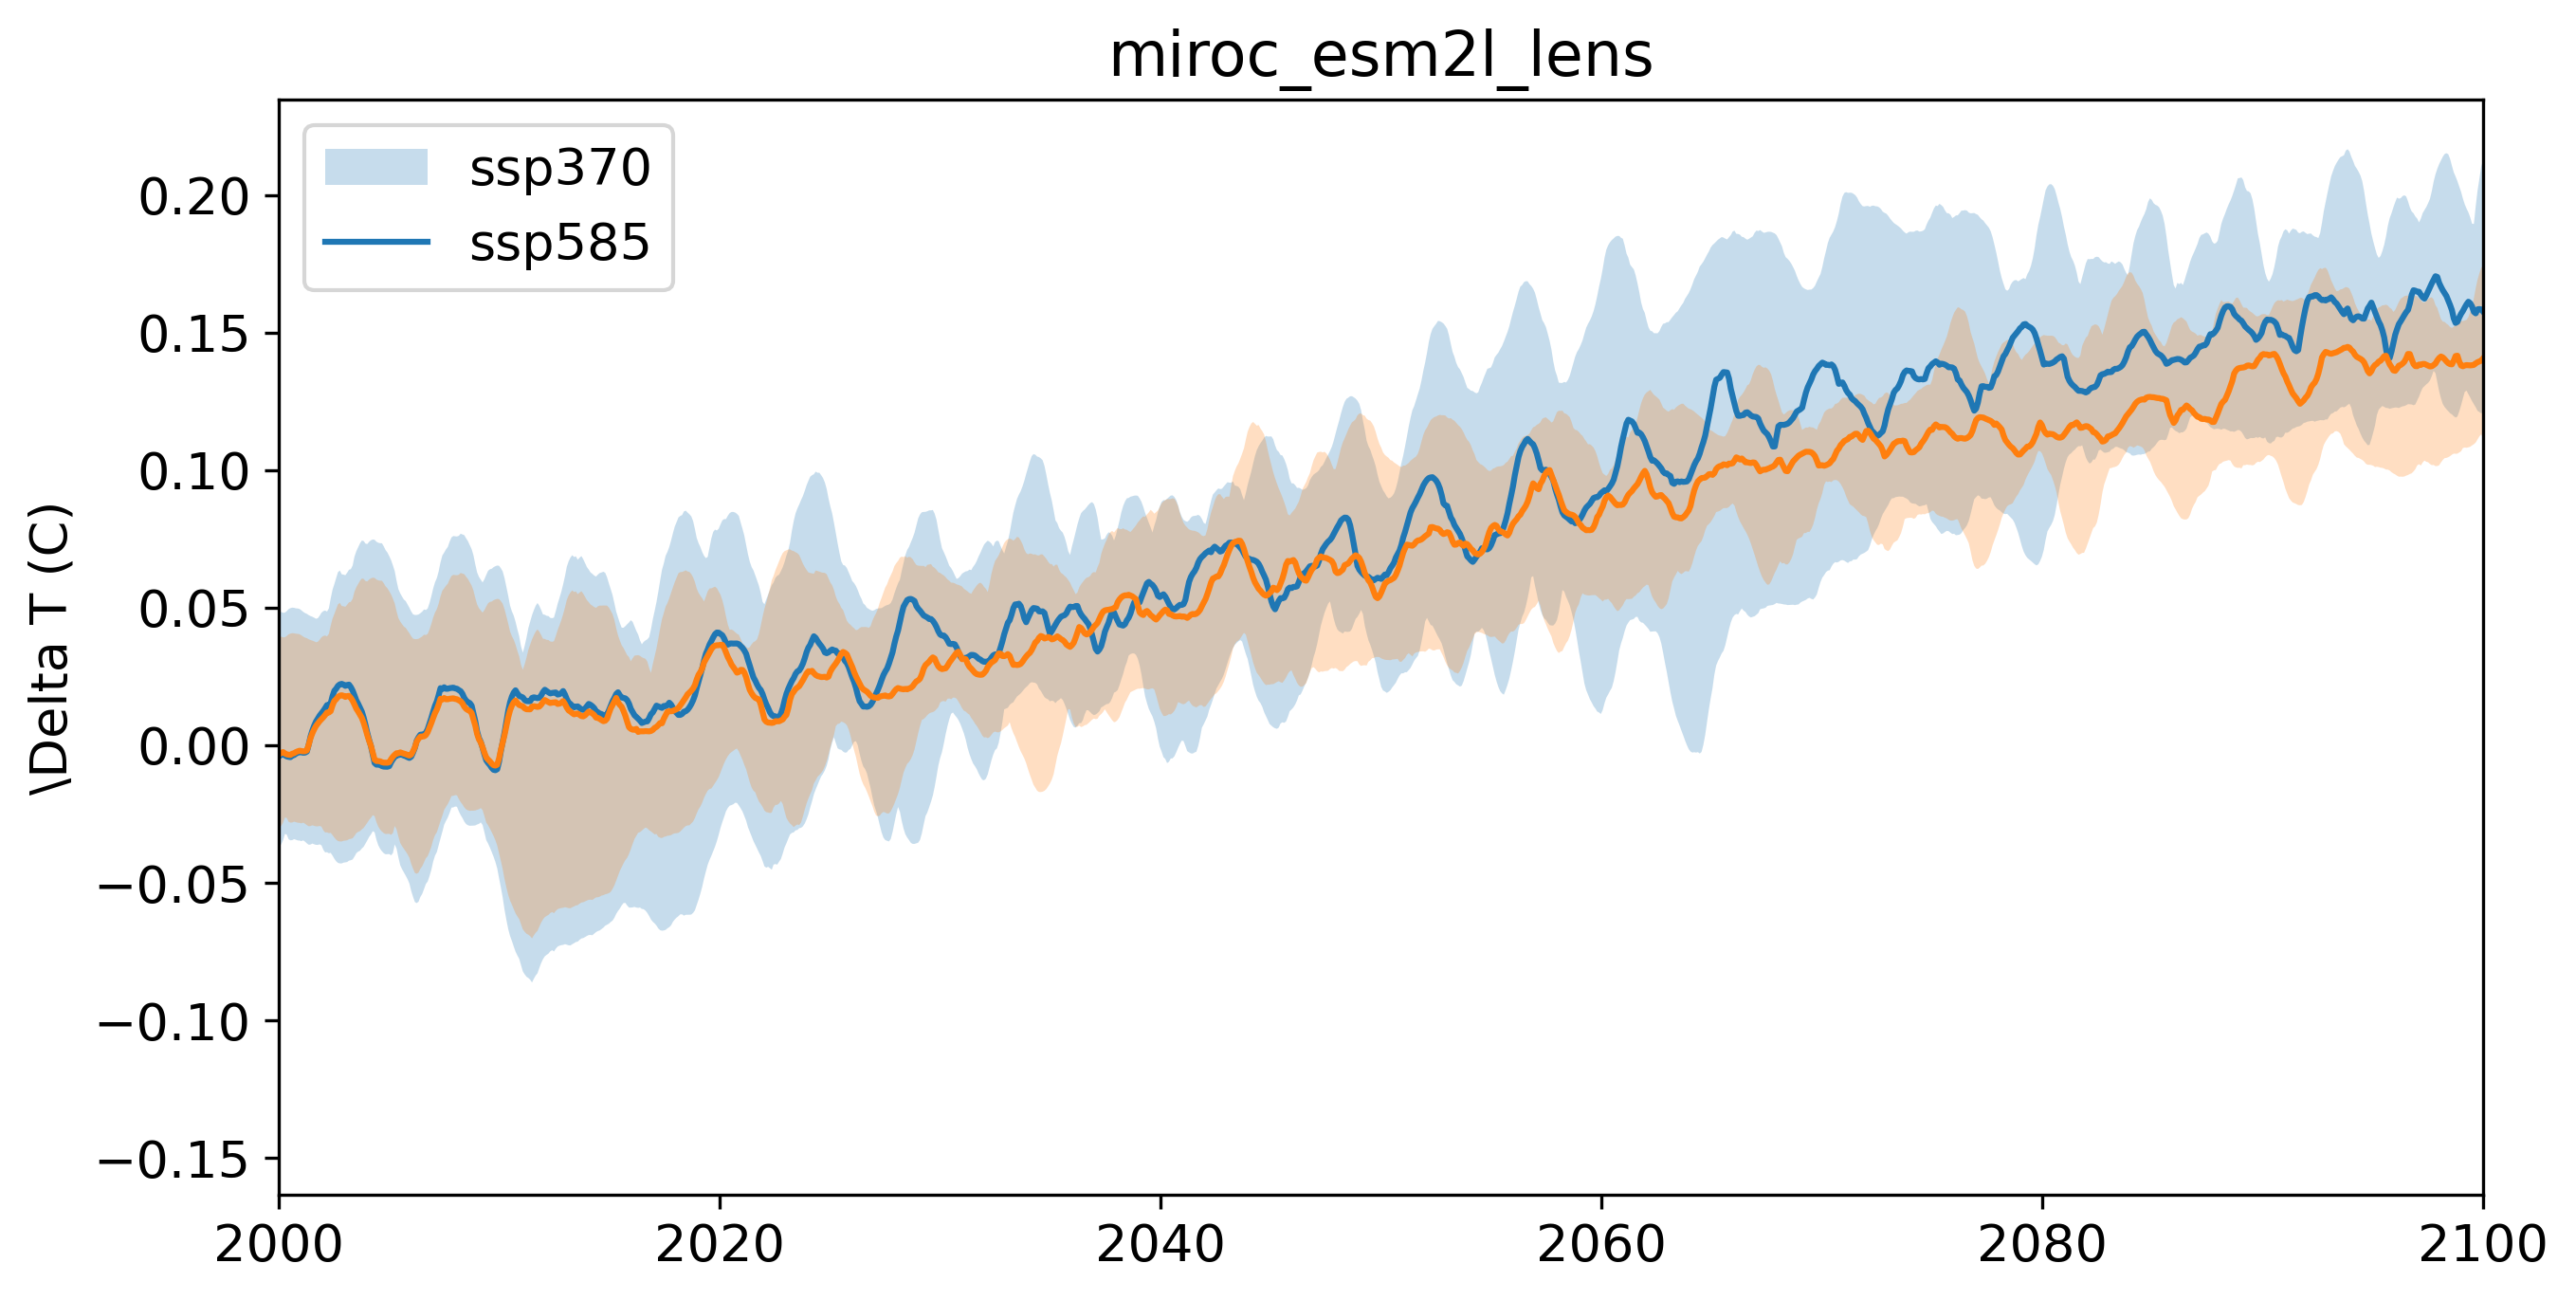

In [6]:
ens_zdiff_arr = np.zeros([len(scenstr), len(mods)])

# Loop over models
for m in tqdm(range(len(mods))):
    print(mods[m])
    fig = plt.figure(figsize=(10, 5), dpi=300)
    ax = fig.add_subplot(111)

    # Loop over scenarios
    scengood = []

    for s in range(len(scenstr)):
        f = os.path.exists('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(epbox[0])+'-'+str(epbox[1])+'N_'+str(epbox[2])+'-'+str(epbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')          

        if f:
            ens_ep = xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(epbox[0])+'-'+str(epbox[1])+'N_'+str(epbox[2])+'-'+str(epbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')
            ens_wp = xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(wpbox[0])+'-'+str(wpbox[1])+'N_'+str(wpbox[2])+'-'+str(wpbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')

            if globTwgt == 1:
                ens_globT = xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/taswgtavg_-90-90N_0-360E'+'_'+mods[m]+'_'+scenstr[s]+'.nc')
                if "e3smv2" in mods[m]:
                    ens_globT = ens_globT.rename({'TS': 'tas'})

        if f:
            scengood.append(scenstr[s])

            if "e3smv2" in mods[m]:
                ens_ep = ens_ep.rename({'TS': 'tas'})
                ens_wp = ens_wp.rename({'TS': 'tas'})

            # Calculate regional average
            ens_ep = ens_ep.mean(dim="lat").mean(dim="lon").squeeze()
            ens_wp = ens_wp.mean(dim="lat").mean(dim="lon").squeeze()

            # Calculate zonal SST gradient
            ens_zgrad = ens_ep-ens_wp

            if globTwgt == 1:
                # Warming = ensemble-mean difference between global T 
                ens_globT_strt = ens_globT.sel(time=slice(str(st_int[0]) + '-01-01', str(st_int[1]) + '-12-31')).mean('time').mean('member').squeeze()
                ens_globT_end = ens_globT.sel(time=slice(str(end_int[0]) + '-01-01', str(end_int[1]) + '-12-31')).mean('time').mean('member').squeeze()

                ens_zgrad = ens_zgrad/(ens_globT_end - ens_globT_strt)

            # Calculate epochal changes for use later
            tmp_zdiff_early = ens_zgrad.sel(time=slice(str(st_int[0])+'-01-01',str(st_int[1])+'-12-31')).mean('time').squeeze()
            tmp_zdiff_late = ens_zgrad.sel(time=slice(str(end_int[0])+'-01-01',str(end_int[1])+'-12-31')).mean('time').squeeze()      
            tmp_zdiff_chg = tmp_zdiff_late - tmp_zdiff_early

            # Calculate gradient over reference period
            tmp_zdiff_ref = ens_zgrad.sel(time=slice(str(st_int[0])+'-01-01',str(st_int[1])+'-12-31')).mean('time').mean('member').squeeze()

            # Calculate running average for plotting purposes, subtract values over a reference period
            zgrad_mn=ens_zgrad.rolling(time=12*windlen).mean() - tmp_zdiff_ref

            # Make plot
            strtyr = np.min(zgrad_mn.time.dt.year)
            endyr = np.max(zgrad_mn.time.dt.year)
            ax.fill_between(np.linspace(strtyr,endyr,len(zgrad_mn.time)),zgrad_mn.tas.min(dim="member"),zgrad_mn.tas.max(dim="member"),alpha=0.25)
            plt.plot(np.linspace(strtyr,endyr,len(zgrad_mn.time)),zgrad_mn.tas.median(dim="member"))
            plt.xlim([2000,2100])
            plt.title(mods[m])
            plt.ylabel('\Delta T (C)')      

            del ens_ep
            del ens_wp

    plt.legend(scengood,loc='upper left')

### 2) Plot all model time series for a given scenario

In the above task, the scaling of the gradient response to CO2 change was assessed by plotting the different scenarios for a given model. Now we can see the inter-model differences in responses to a given scenario!

  0%|          | 0/4 [00:00<?, ?it/s]

/glade/derecho/scratch/samantha/plots/ENSOworkshop/timeseries_zonalsstgrad_ssp126_globTwgt.pdf


 25%|██▌       | 1/4 [00:01<00:04,  1.63s/it]

/glade/derecho/scratch/samantha/plots/ENSOworkshop/timeseries_zonalsstgrad_ssp245_globTwgt.pdf


 50%|█████     | 2/4 [00:03<00:03,  1.71s/it]

/glade/derecho/scratch/samantha/plots/ENSOworkshop/timeseries_zonalsstgrad_ssp370_globTwgt.pdf


 75%|███████▌  | 3/4 [00:05<00:02,  2.05s/it]

/glade/derecho/scratch/samantha/plots/ENSOworkshop/timeseries_zonalsstgrad_ssp585_globTwgt.pdf


100%|██████████| 4/4 [00:08<00:00,  2.14s/it]


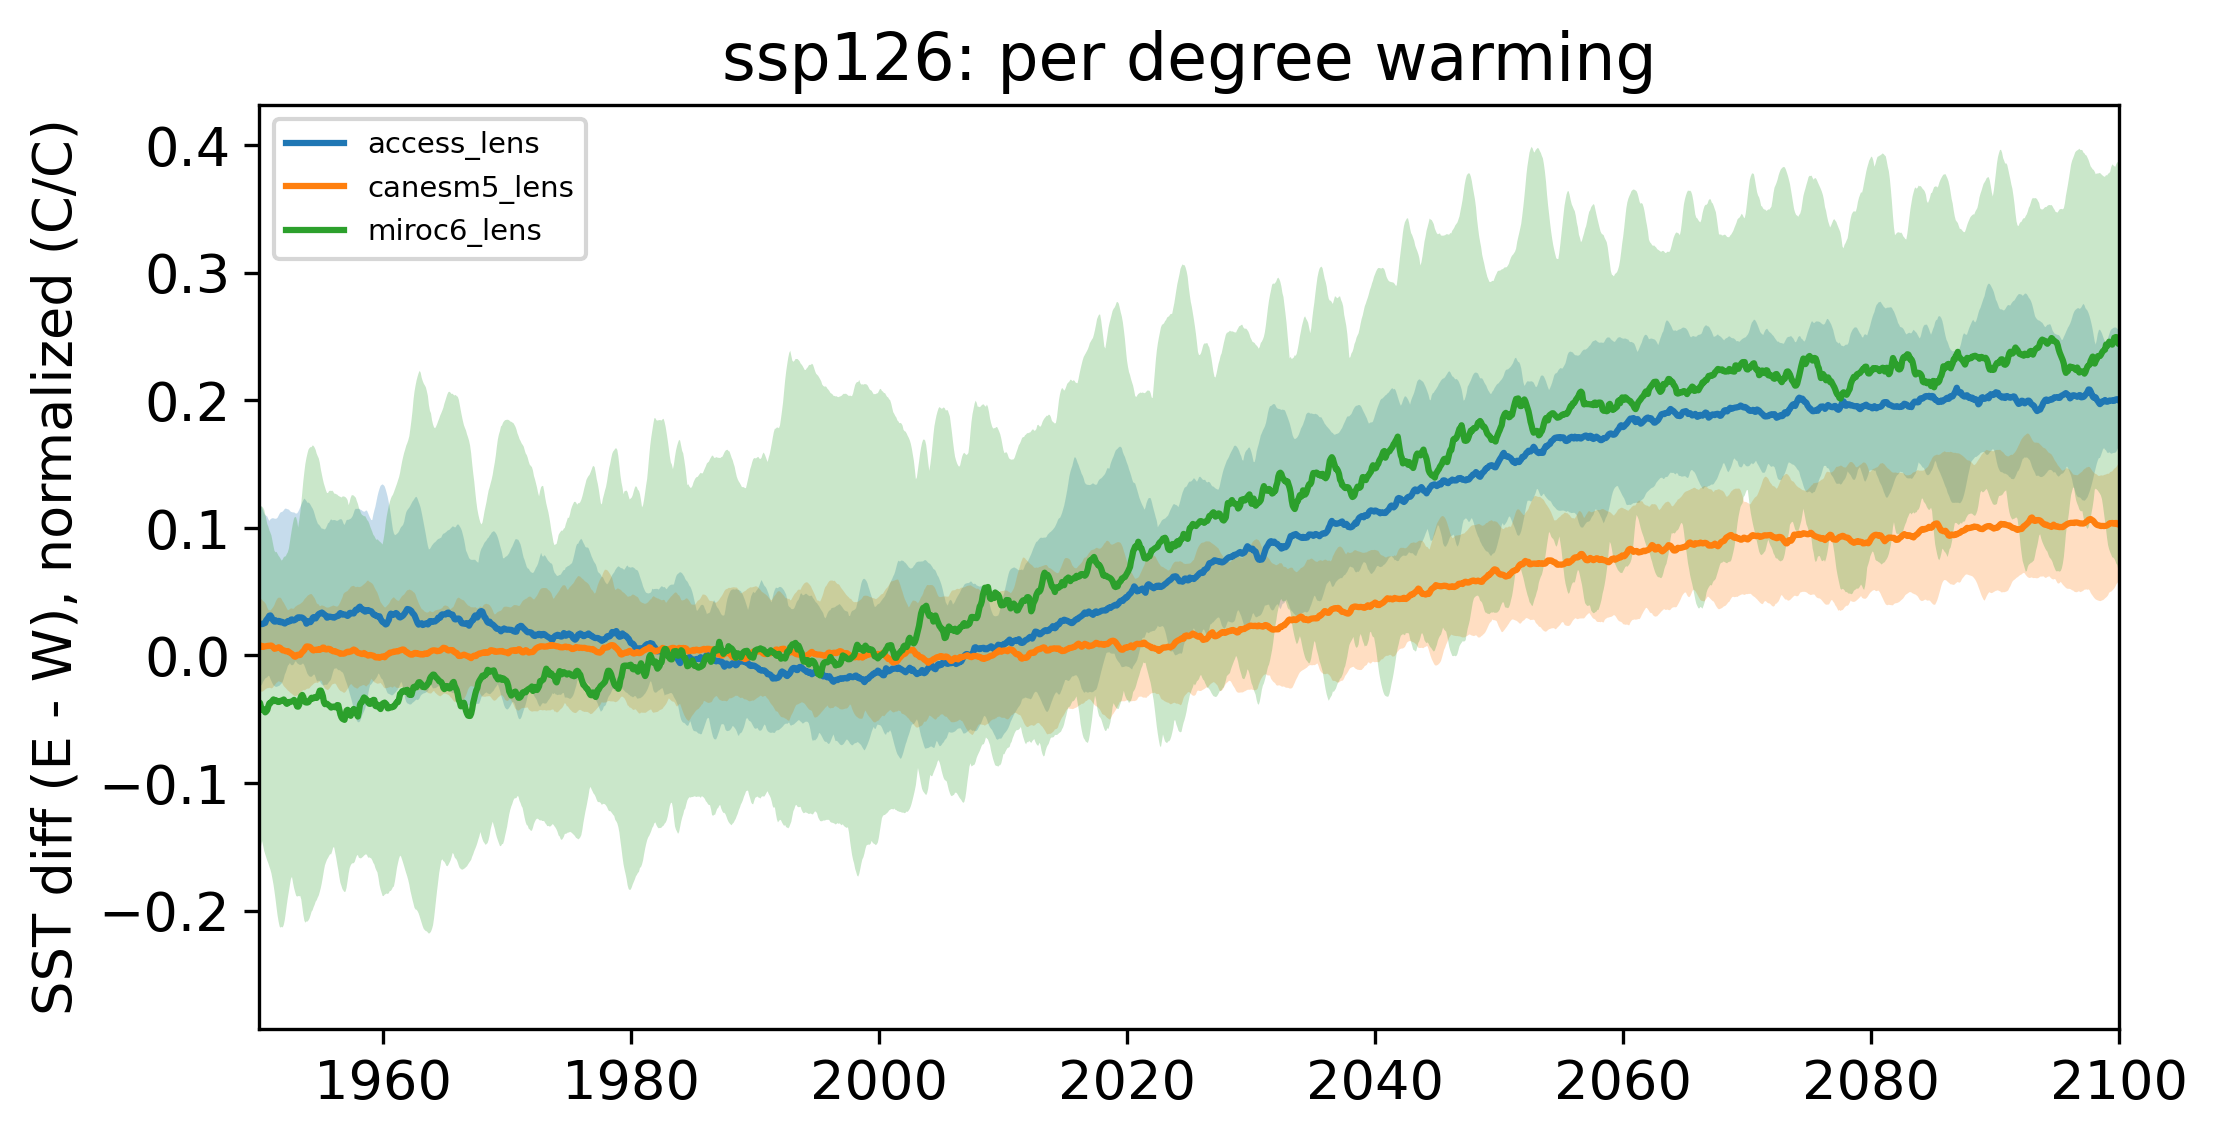

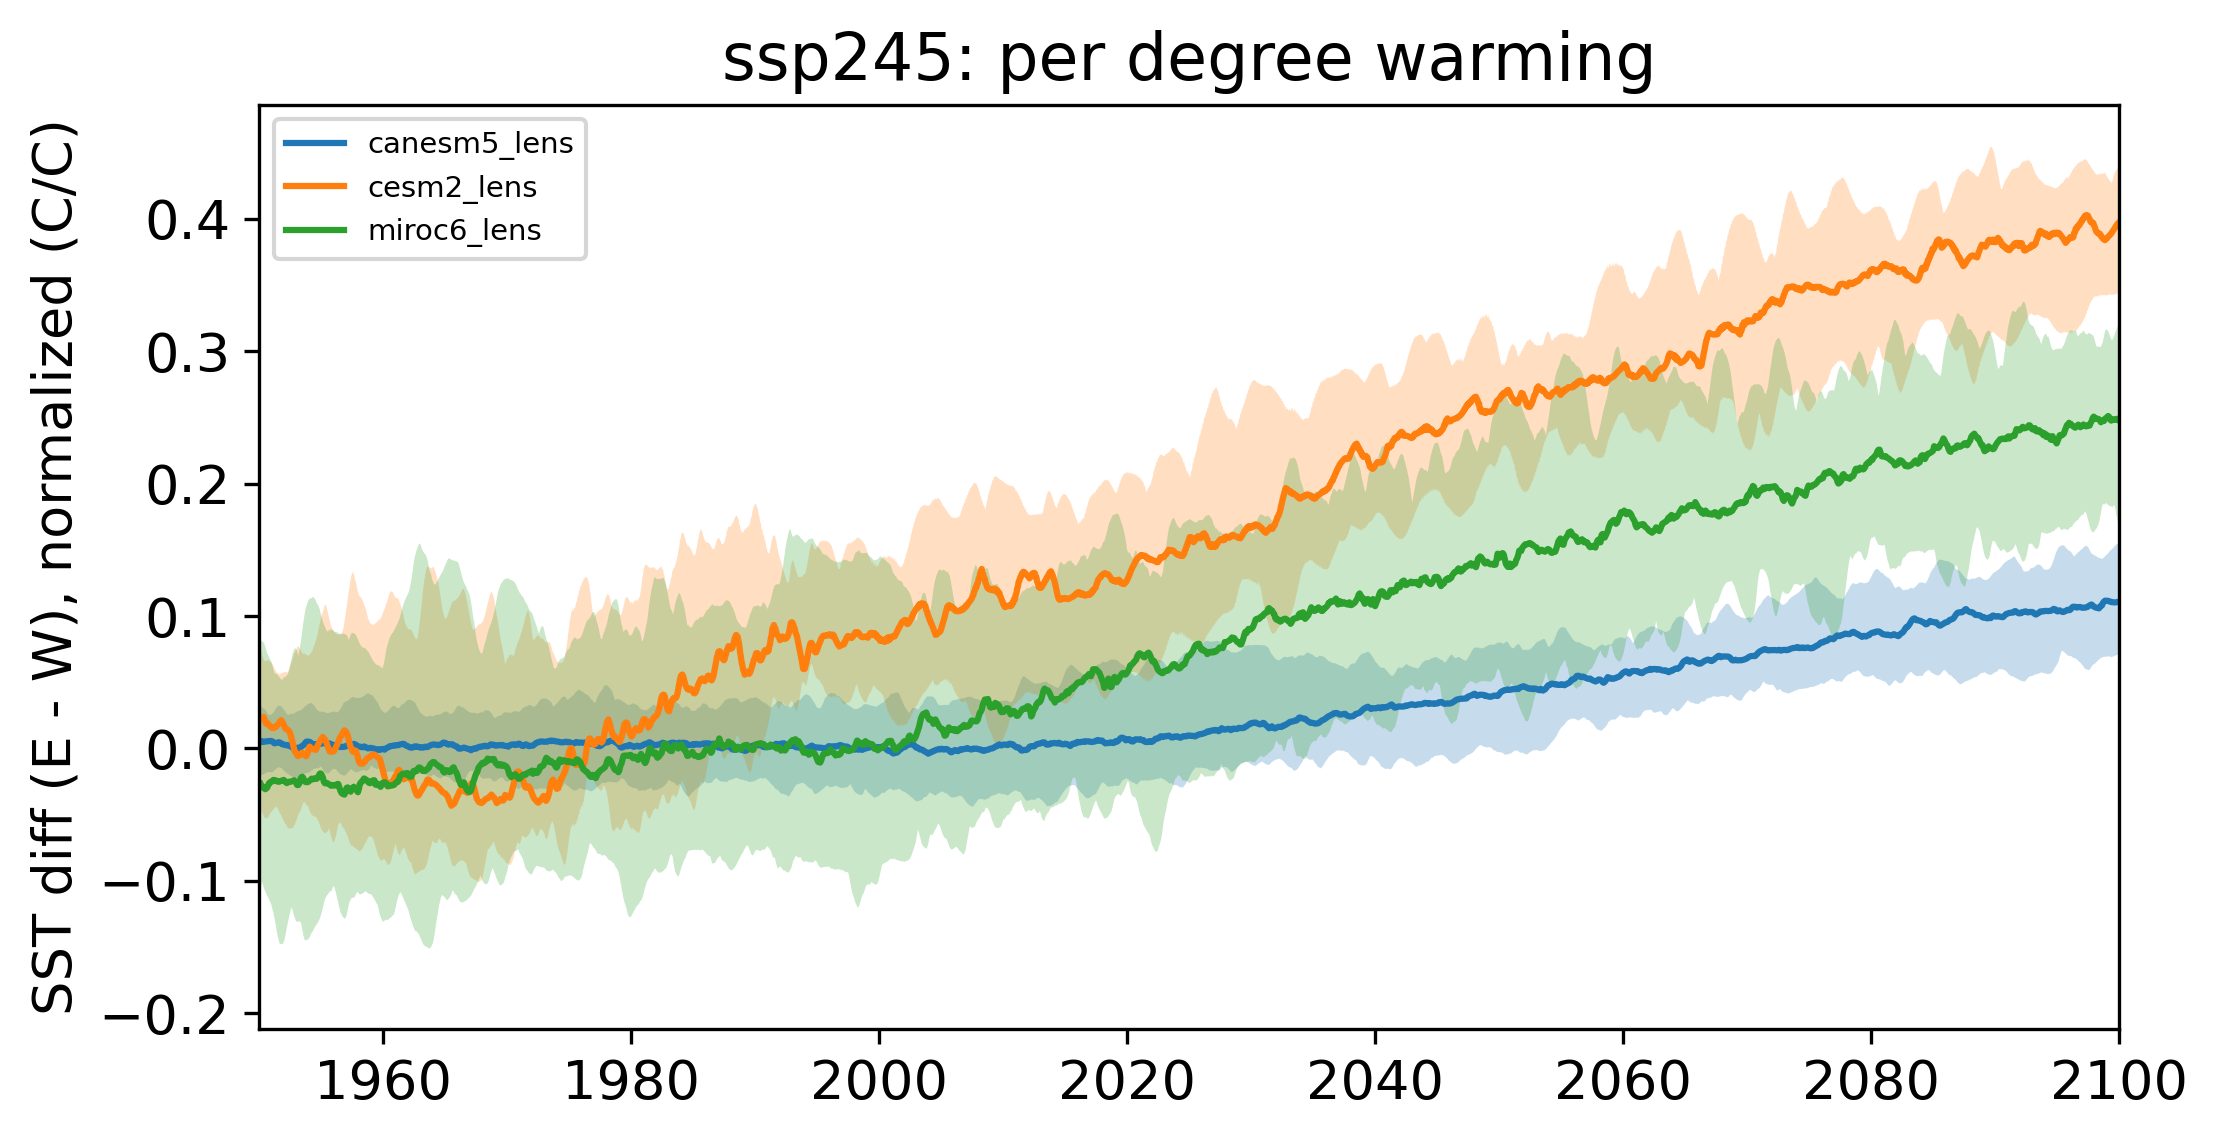

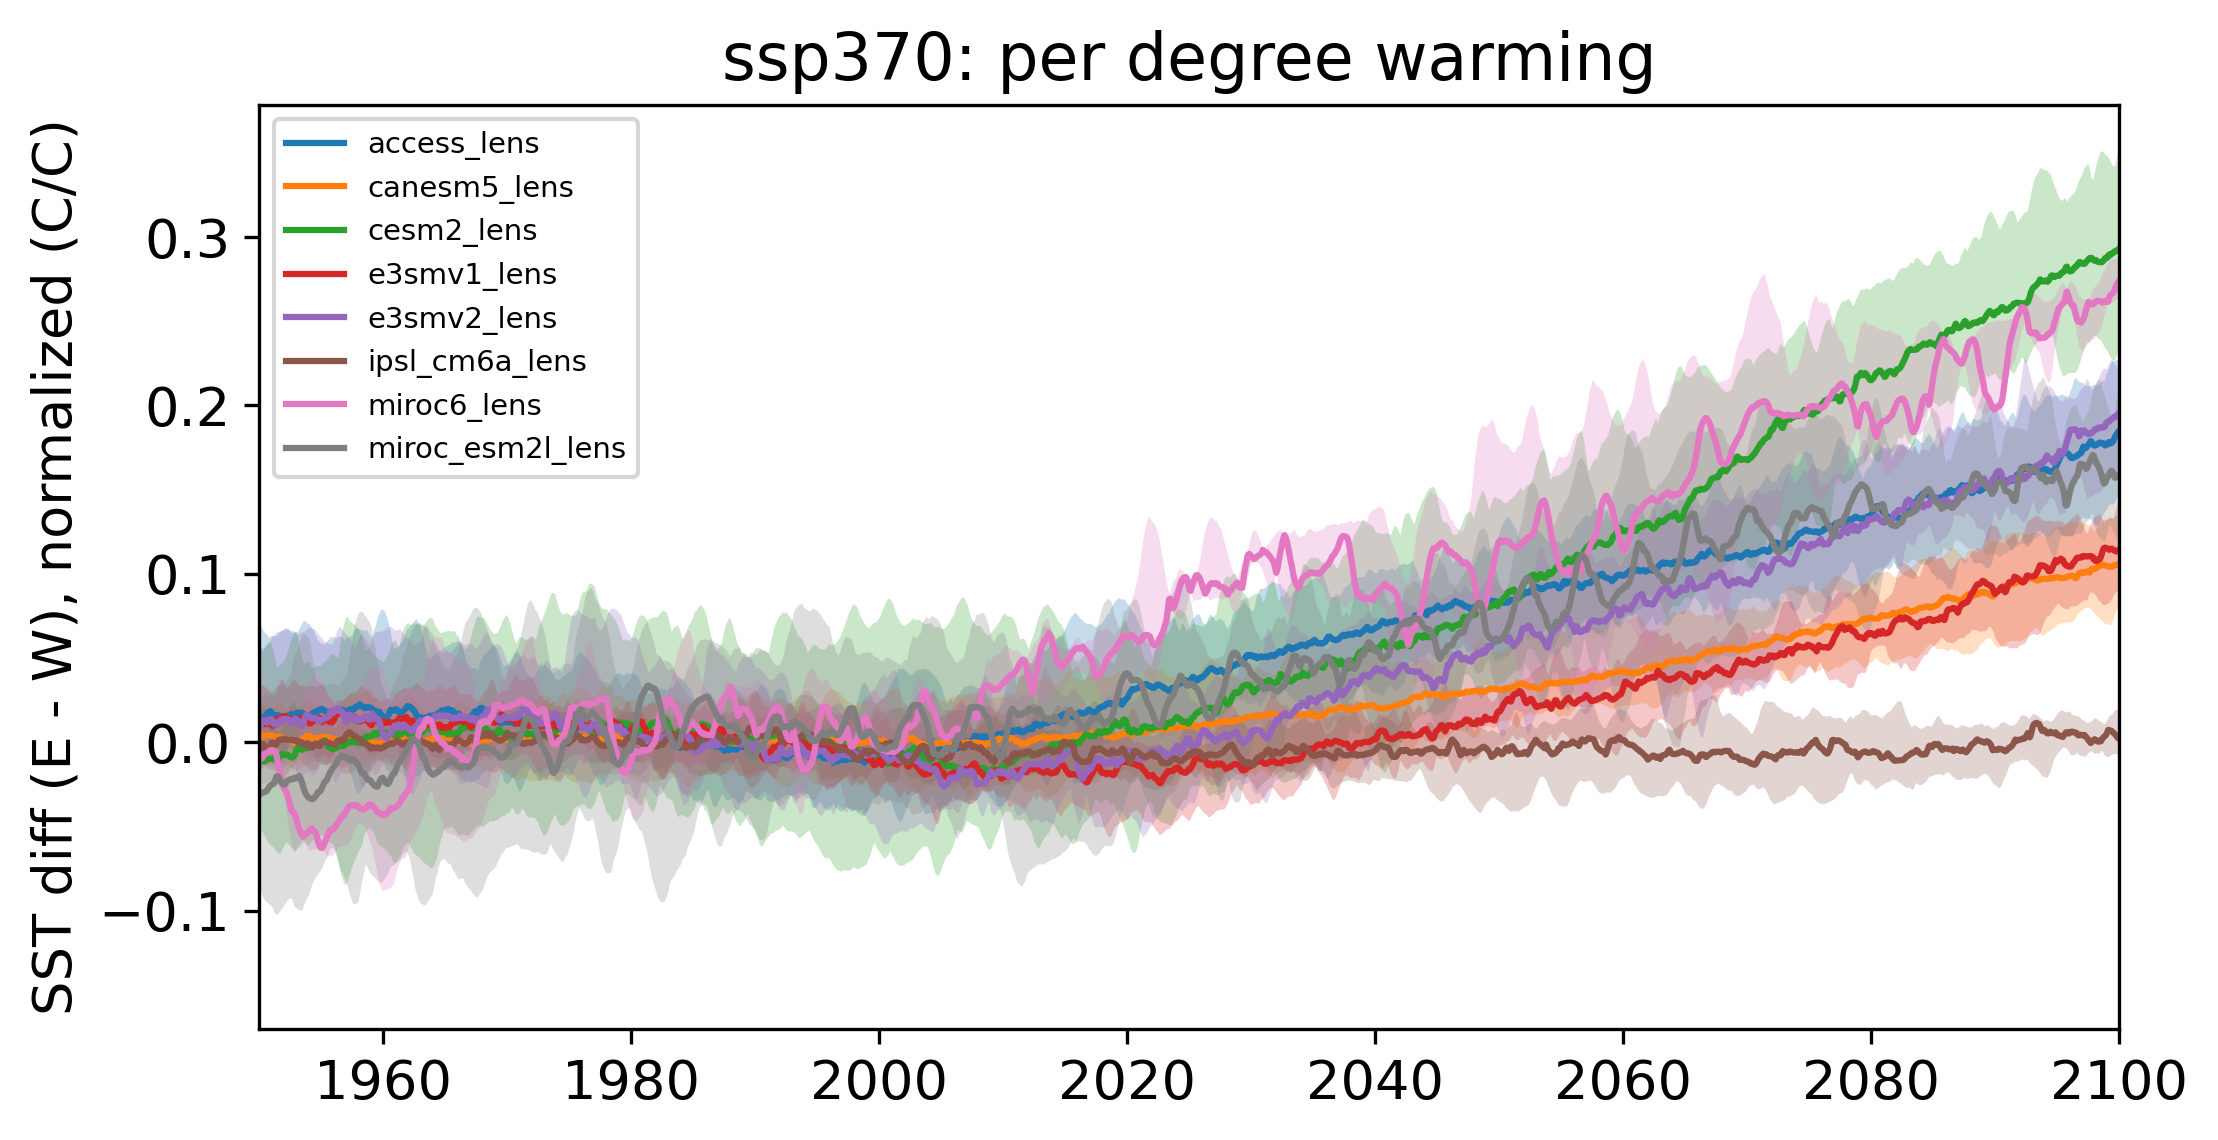

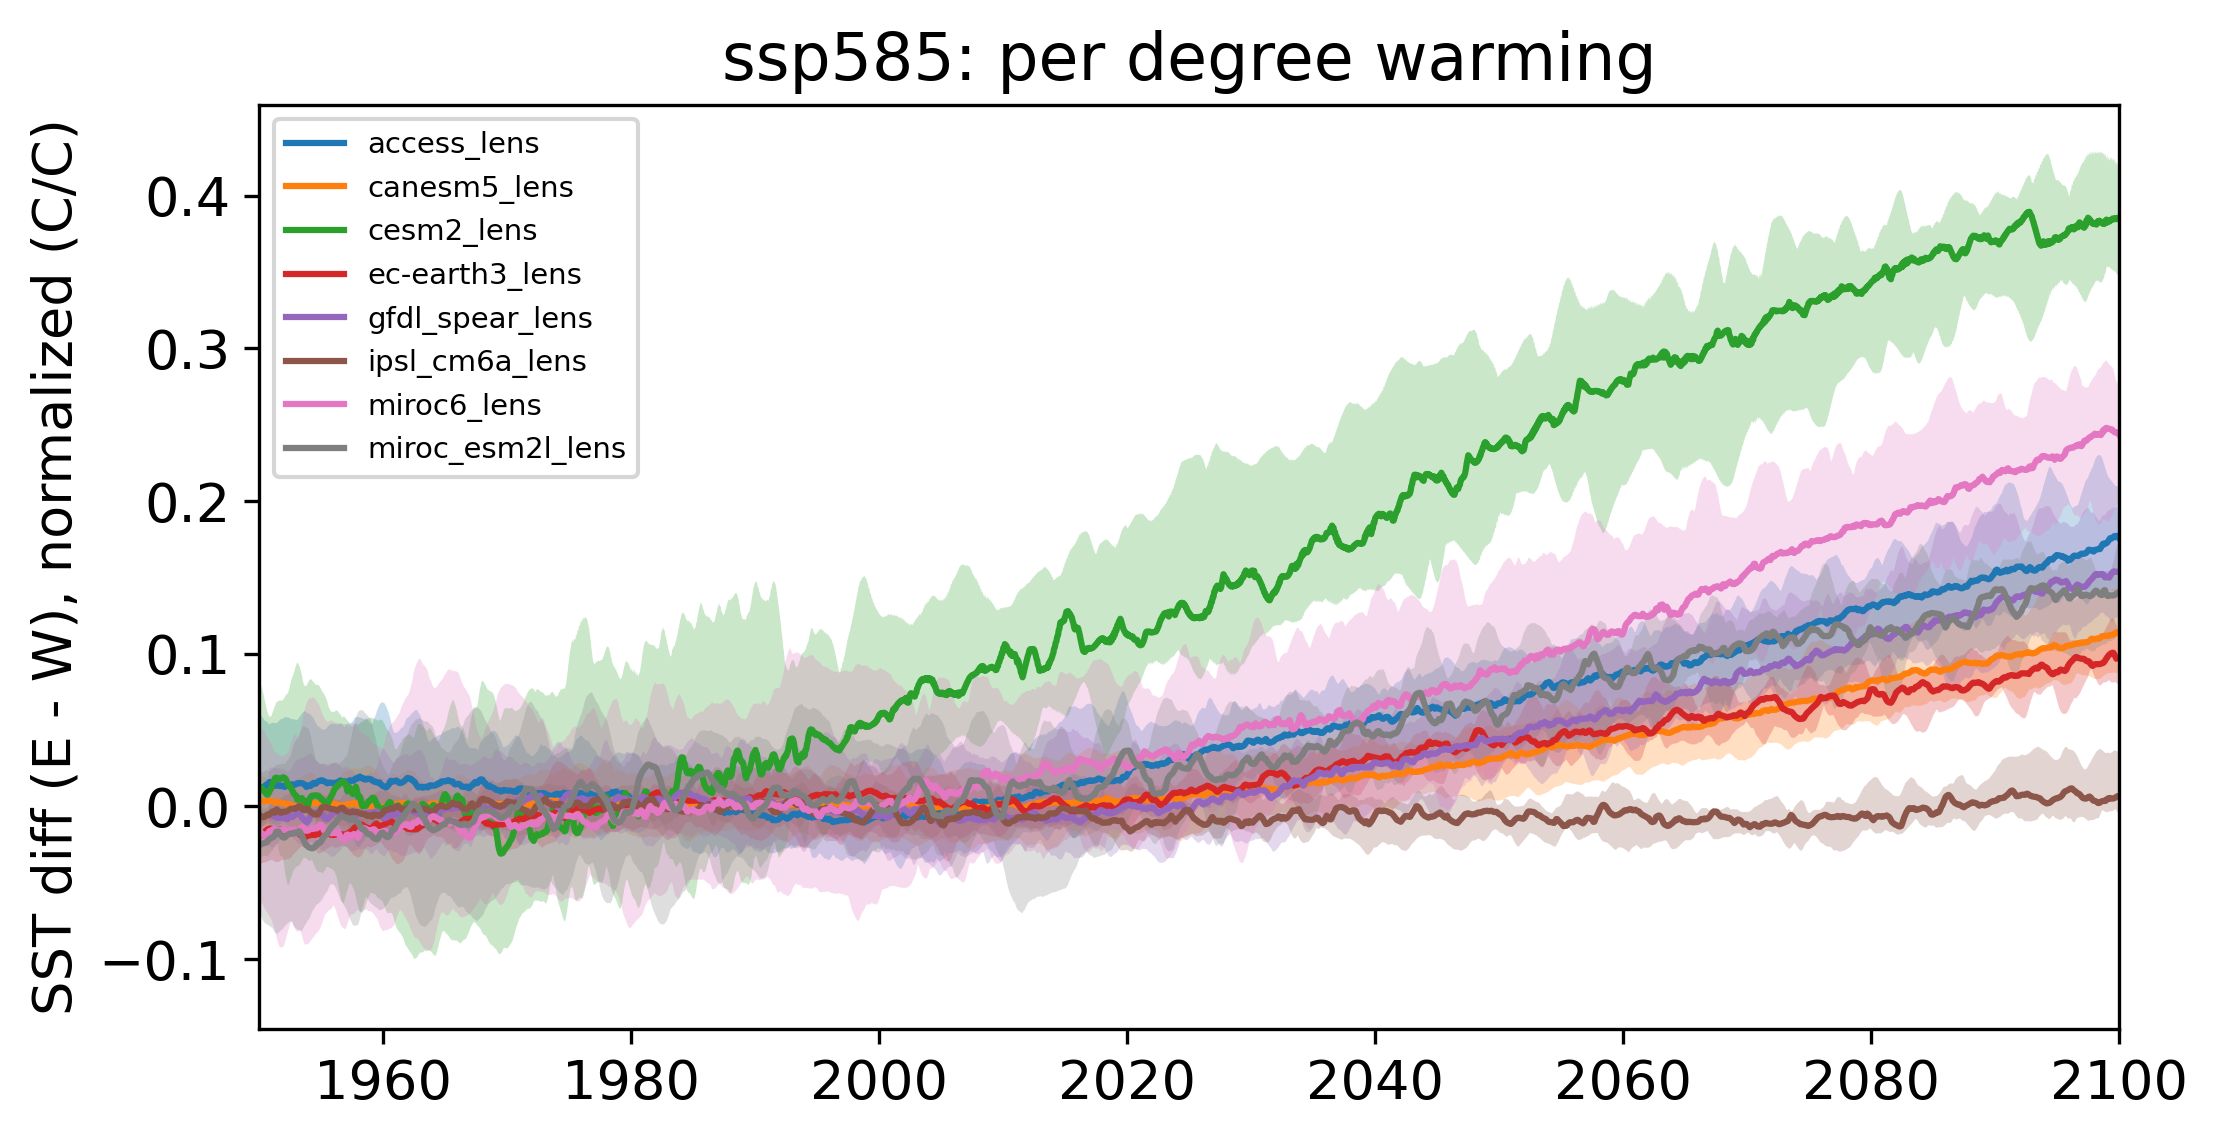

In [7]:
# Loop over scenarios
for s in tqdm(range(len(scenstr))):
#for s in range(1):
    fig=plt.figure(figsize=(8, 4), dpi=300)
    ax = fig.add_subplot(111)

    modgood = []
    pltobj = []

    # Loop over models
    for m in range(len(mods)):
        f=os.path.exists('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(epbox[0])+'-'+str(epbox[1])+'N_'+str(epbox[2])+'-'+str(epbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')

        if f:
            ens_ep=xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(epbox[0])+'-'+str(epbox[1])+'N_'+str(epbox[2])+'-'+str(epbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')
            ens_wp=xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(wpbox[0])+'-'+str(wpbox[1])+'N_'+str(wpbox[2])+'-'+str(wpbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')

            if globTwgt == 1:
                ens_globT=xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/taswgtavg_-90-90N_0-360E'+'_'+mods[m]+'_'+scenstr[s]+'.nc')
                if "e3smv2" in mods[m]:
                    ens_globT = ens_globT.rename({'TS': 'tas'})

        if f:
            modgood.append(mods[m])

            if "e3smv2" in mods[m]:
                ens_ep = ens_ep.rename({'TS': 'tas'})
                ens_wp = ens_wp.rename({'TS': 'tas'})

            # Calculate regional average
            ens_ep = ens_ep.mean(dim="lat").mean(dim="lon").squeeze()
            ens_wp = ens_wp.mean(dim="lat").mean(dim="lon").squeeze()

            # Calculate zonal SST gradient
            ens_zgrad = ens_ep-ens_wp

            # Calculate DJF average
            # tmpdjf = ens_zgrad.resample(time='QS-DEC').mean(dim="time")
            # tmpdjf = tmpdjf.where(tmpdjf.time.dt.month == 12,drop="True")
            # ens_zgrad = tmpdjf

            if globTwgt == 1:
                # tmpdjf = ens_globT.resample(time='QS-DEC').mean(dim="time")
                # tmpdjf = tmpdjf.where(tmpdjf.time.dt.month == 12,drop="True")

                # Warming = ensemble-mean difference between global T in first/last 30 years of simulation
                ens_globT_strt = ens_globT.sel(time=slice(str(st_int[0])+'-01-01',str(st_int[1])+'-12-31')).mean('time').mean('member').squeeze()
                ens_globT_end = ens_globT.sel(time=slice(str(end_int[0])+'-01-01',str(end_int[1])+'-12-31')).mean('time').mean('member').squeeze()
                ens_globTdiff = ens_globT_end - ens_globT_strt

                ens_zgrad = ens_zgrad/(ens_globT_end - ens_globT_strt)

            # Calculate gradient over reference period
            tmp_zdiff_ref = ens_zgrad.sel(time=slice(str(st_int[0])+'-01-01',str(st_int[1])+'-12-31')).mean('time').mean('member').squeeze()

            # Calculate running average for plotting purposes
            zgrad_mn=ens_zgrad.rolling(time=12*windlen).mean() - tmp_zdiff_ref

            # Make plot
            strtyr=np.min(zgrad_mn.time.dt.year)
            endyr=np.max(zgrad_mn.time.dt.year)
            ax.fill_between(np.linspace(strtyr,endyr,len(zgrad_mn.time)),zgrad_mn.tas.min(dim="member"),zgrad_mn.tas.max(dim="member"),alpha=0.25)
            ptmp,=plt.plot(np.linspace(strtyr,endyr,len(zgrad_mn.time)),zgrad_mn.tas.median(dim="member"))
            
            #ptmp,=plt.plot(np.linspace(strtyr,endyr,len(zgrad_mn.time)),ens_globTdiff.tas- ens_globT_strt.tas)
            plt.xlim([1950,2100])
            #plt.ylim([-0.4,0.4])
            if globTwgt == 1:
                plt.ylabel('SST diff (E - W), normalized (C/C)')      
                plt.title(scenstr[s]+': per degree warming')
            else:
                plt.ylabel('SST diff (E - W)')      
                plt.title(scenstr[s])

            pltobj.append(ptmp)
            del ens_ep
            del ens_wp
            
    plt.legend(pltobj,modgood,loc='upper left',fontsize=7)
    if globTwgt == 1:
        print(plotdir+'timeseries_zonalsstgrad_'+scenstr[s]+'_globTwgt.pdf')
        plt.savefig(plotdir+'timeseries_zonalsstgrad_'+scenstr[s]+'_globTwgt.pdf', format='pdf', bbox_inches='tight', dpi=300)
    else:
        print(plotdir+'timeseries_zonalsstgrad_'+scenstr[s]+'.pdf')
        plt.savefig(plotdir+'timeseries_zonalsstgrad_'+scenstr[s]+'.pdf', format='pdf', bbox_inches='tight', dpi=300)


### 3) Plot magnitude of gradient change versus CO2 concentration change

It looks from other notebooks like the El Nino-like warming signal scales with the amplitude of forcing, but I want to see how true that is quantitatively.

100%|██████████| 10/10 [00:06<00:00,  1.49it/s]


/glade/derecho/scratch/samantha/plots/ENSOworkshop/epochdiff_zonalsstgrad_globTwgt_1950-2000_vs_2050-2100.pdf


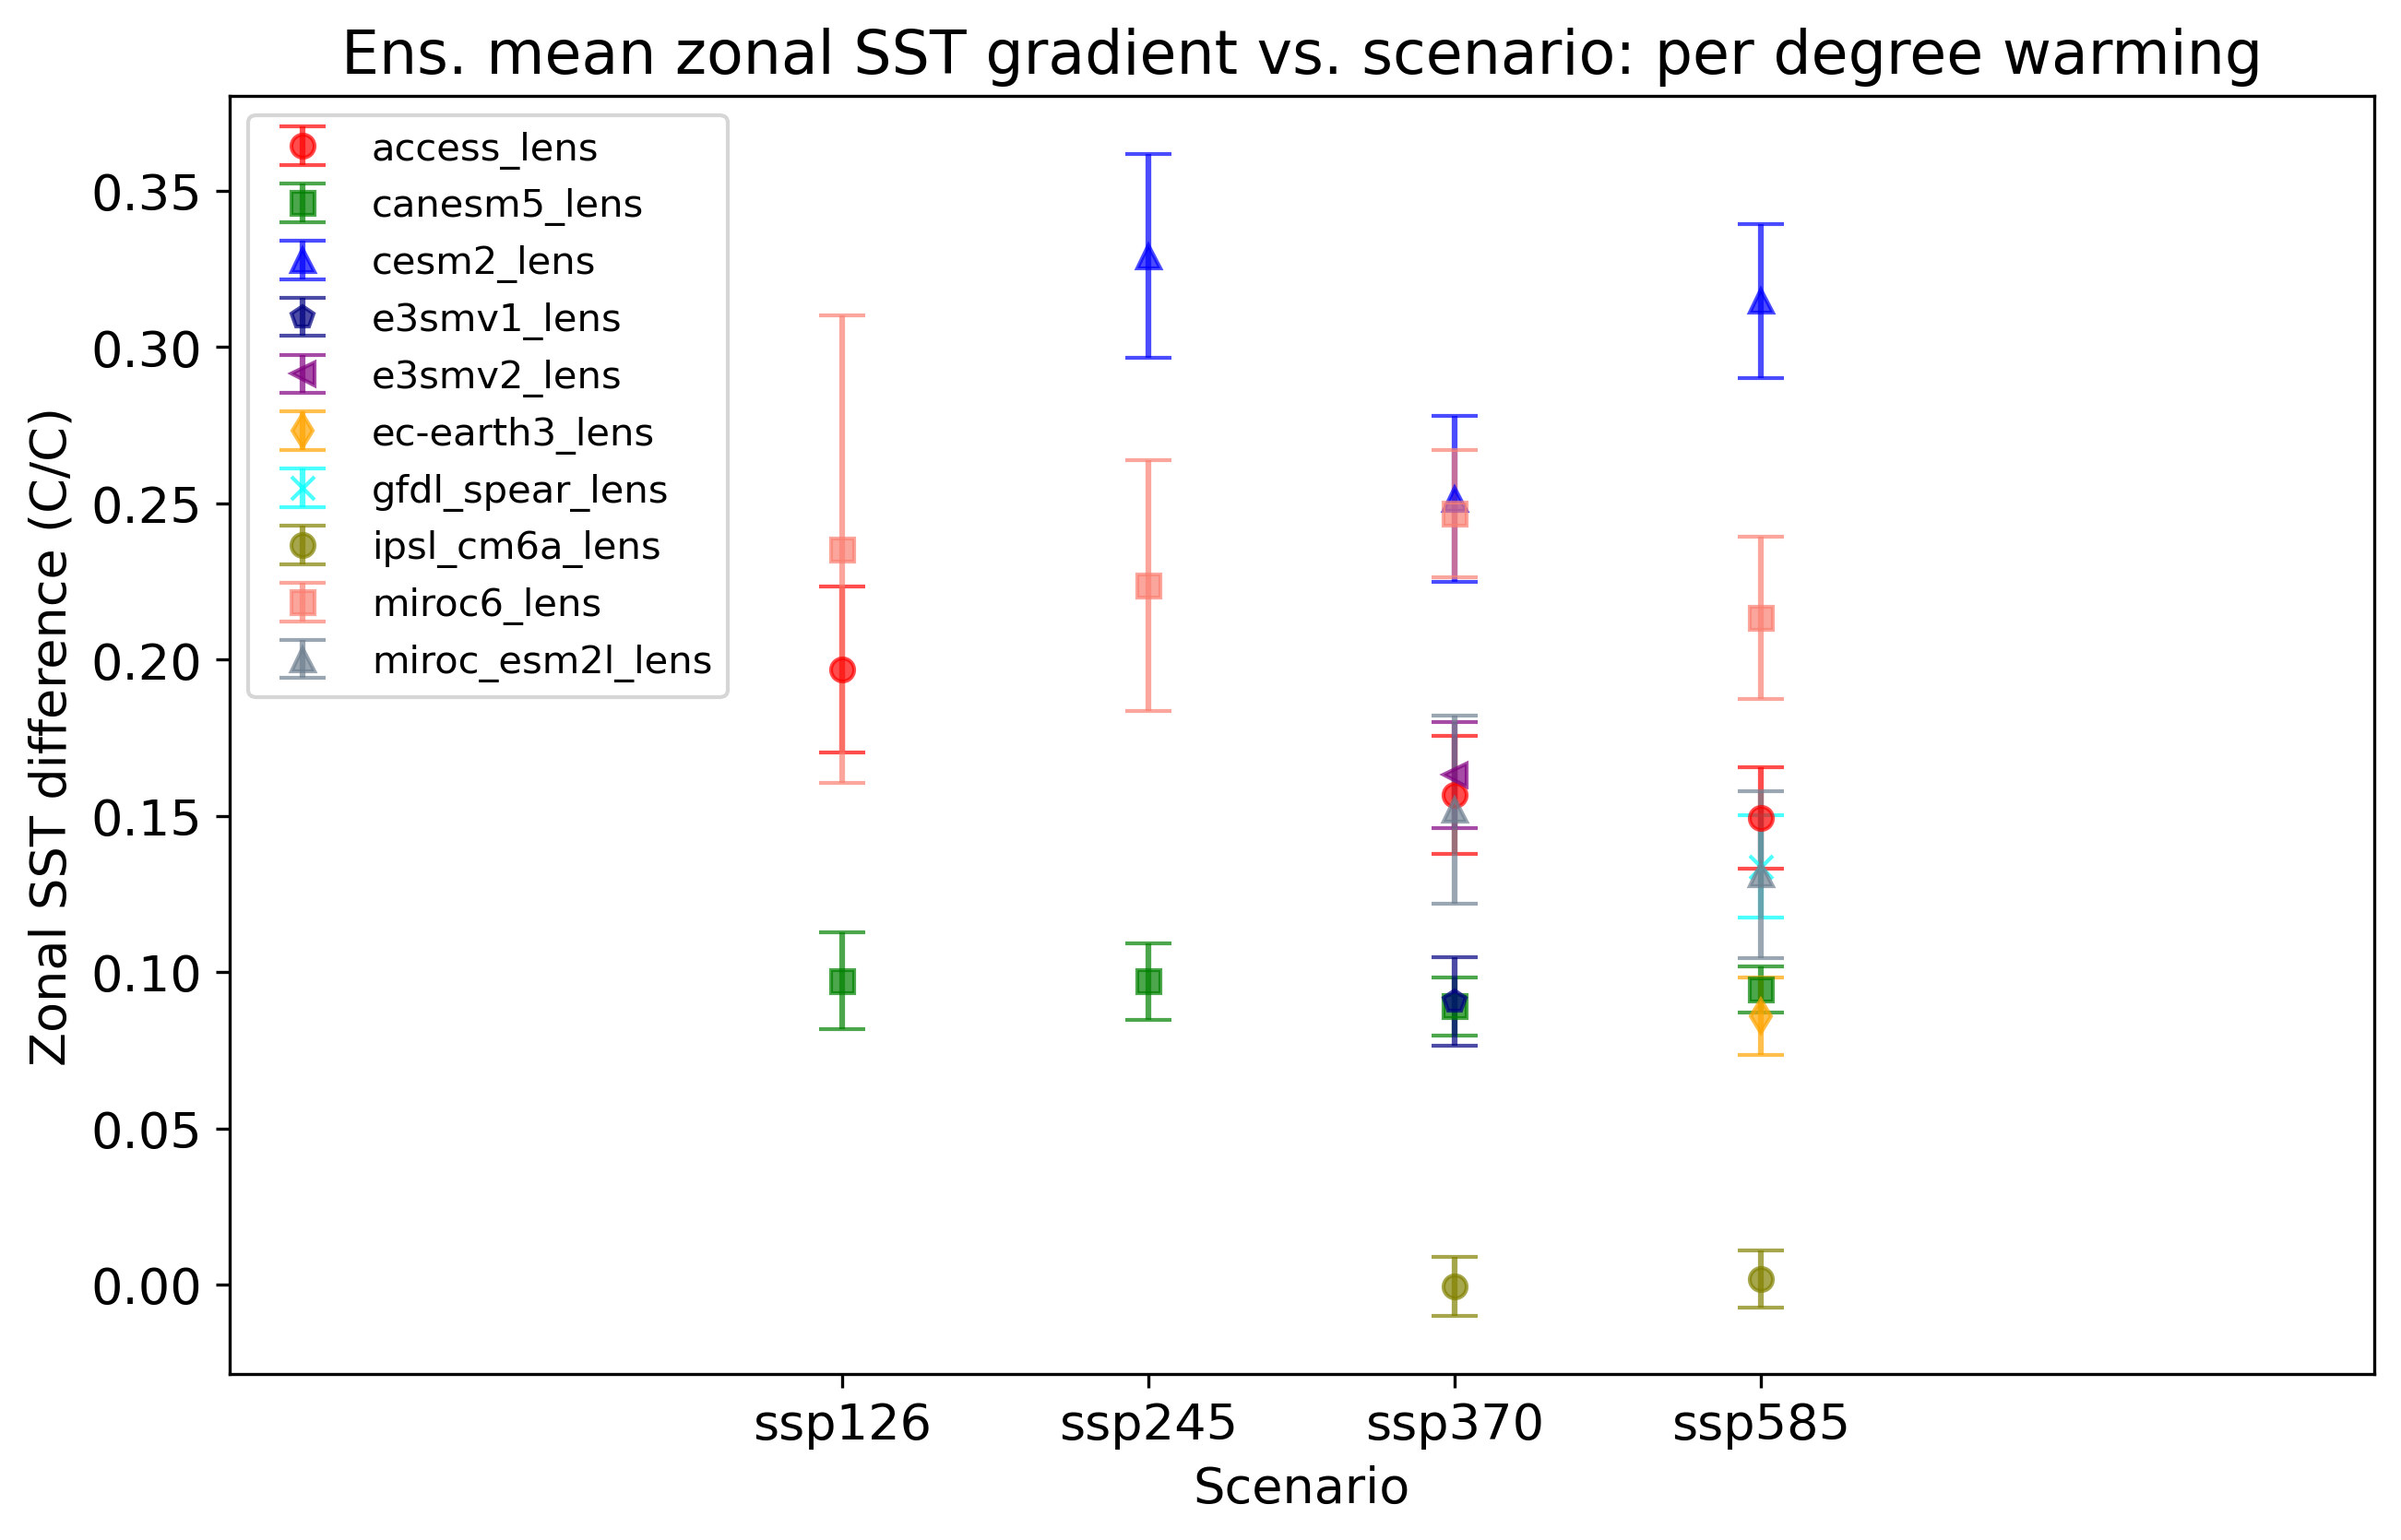

In [8]:
plt.figure(figsize=(10, 6), dpi=300)

sym=['o','s','^','p','<','d','x','o','s','^','p','<','d','x','.','>']
cols=['red','green','blue','navy','purple','orange','cyan','olive','salmon','slategray','darkcyan','springgreen','saddlebrown','black','pink','deepskyblue']
newmodscaps=[]

ensmn_arr=np.empty([len(scenstr),len(mods)])
ensmn_arr.fill(np.NaN)
ensstd_arr=np.empty([len(scenstr),len(mods)])
ensstd_arr.fill(np.NaN)
enstrend_arr=np.empty([len(scenstr),len(mods)])
enstrend_arr.fill(np.NaN)

for m in tqdm(range(len(mods))):
#for m in range(1):
    newmodscaps.append(mods[m])

    for s in range(len(scenstr)):
        #print(mods[m])
        #print(scenstr[s])
        f=os.path.exists('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(epbox[0])+'-'+str(epbox[1])+'N_'+str(epbox[2])+'-'+str(epbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')          

        if f:
            #print(mods[m])
            #print(scenstr[s])
            ens_ep=xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(epbox[0])+'-'+str(epbox[1])+'N_'+str(epbox[2])+'-'+str(epbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')
            ens_wp=xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/tas_'+str(wpbox[0])+'-'+str(wpbox[1])+'N_'+str(wpbox[2])+'-'+str(wpbox[3])+'E_'+mods[m]+'_'+scenstr[s]+'.nc')

            if globTwgt == 1:
                ens_globT=xr.open_dataset('/glade/derecho/scratch/samantha/ENSOemergconstr/taswgtavg_-90-90N_0-360E'+'_'+mods[m]+'_'+scenstr[s]+'.nc')

            # Calculate regional average
            ens_ep = ens_ep.mean(dim="lat").mean(dim="lon").squeeze()
            ens_wp = ens_wp.mean(dim="lat").mean(dim="lon").squeeze()

            # Calculate zonal SST gradient
            ens_zgrad = ens_ep-ens_wp

            if globTwgt == 1:
                # Warming = ensemble-mean difference in global T 
                ens_globT_strt = ens_globT.sel(time=slice(str(st_int[0])+'-01-01',str(st_int[1])+'-12-31')).mean('time').mean('member').squeeze()
                ens_globT_end = ens_globT.sel(time=slice(str(end_int[0])+'-01-01',str(end_int[1])+'-12-31')).mean('time').mean('member').squeeze()

                #normalize
                ens_zgrad = ens_zgrad/(ens_globT_end - ens_globT_strt)

            # Calculate linear trends over full simulation period
            tmp = ens_zgrad.sel(time=slice('1950-01-01','2100-12-31')).mean('member').polyfit(dim = "time", deg = 1)
            if "e3smv2" in mods[m]:
                ens_trend = tmp.TS_polyfit_coefficients[0]*10*31556952*1e9
            else:
                ens_trend = tmp.tas_polyfit_coefficients[0]*10*31556952*1e9
            enstrend_arr[s,m] = ens_trend

            # Calculate epochal changes 
            tmp_zdiff_early = ens_zgrad.sel(time=slice(str(st_int[0]) + '-01-01', str(st_int[1]) + '-12-31')).mean('time').squeeze()
            tmp_zdiff_late = ens_zgrad.sel(time=slice(str(end_int[0]) + '-01-01', str(end_int[1]) + '-12-31')).mean('time').squeeze()      
            tmp_zdiff_chg = tmp_zdiff_late - tmp_zdiff_early

            if "e3smv2" in mods[m]:
                ensmn_arr[s,m]=np.mean(tmp_zdiff_chg.TS)
                ensstd_arr[s,m]=np.std(tmp_zdiff_chg.TS)
            else:
                ensmn_arr[s,m]=np.mean(tmp_zdiff_chg.tas)
                ensstd_arr[s,m]=np.std(tmp_zdiff_chg.tas)

    # Plot error bar corresponding to the ensemble mean +/- 1 std dev of trend
    plt.errorbar(np.arange(len(scenstr)),ensmn_arr[:,m],yerr=ensstd_arr[:,m],fmt=sym[m],color=cols[m],alpha=0.7,capsize=6)

if globTwgt == 1:
    plt.title('Ens. mean zonal SST gradient vs. scenario: per degree warming')
    plt.ylabel('Zonal SST difference (C/C)')
else:
    plt.title('Ens. mean zonal SST gradient vs. scenario')
    plt.ylabel('Zonal SST difference (C)')
plt.xlabel('Scenario')
plt.xlim([-2,5])
#plt.ylim([-1,1])
plt.xticks(range(len(scenstr)), scenstr)
plt.legend(newmodscaps,loc='upper left',fontsize=10)

if globTwgt == 1:
    print(plotdir+'epochdiff_zonalsstgrad_globTwgt_'+str(st_int[0])+'-'+str(st_int[1])+'_vs_'+str(end_int[0])+'-'+str(end_int[1])+'.pdf')
    plt.savefig(plotdir+'epochdiff_zonalsstgrad_globTwgt_'+str(st_int[0])+'-'+str(st_int[1])+'_vs_'+str(end_int[0])+'-'+str(end_int[1])+'.pdf', format='pdf', bbox_inches='tight', dpi=300)
else:
    print(plotdir+'epochdiff_zonalsstgrad_'+str(st_int[0])+'-'+str(st_int[1])+'_vs_'+str(end_int[0])+'-'+str(end_int[1])+'.pdf')
    plt.savefig(plotdir+'epochdiff_zonalsstgrad_'+str(st_int[0])+'-'+str(st_int[1])+'_vs_'+str(end_int[0])+'-'+str(end_int[1])+'.pdf', format='pdf', bbox_inches='tight', dpi=300)

#plt.savefig(plotdir+'deltaNINO34stddev_vsdeltazonalgrad_'+str(st_int[0])+'-'+str(st_int[1])+'_vs_'+str(end_int[0])+'-'+str(end_int[1])+'_ensmean_tails.pdf', format='pdf', bbox_inches='tight', dpi=300)


In [9]:
# Calculate SST gradient sensitivities, including uncertainty due to scenario differences
for m in tqdm(range(len(mods))):
    print(mods[m])
    print(np.nanmean(ensmn_arr[:,m]))
    print(np.nanmax(ensmn_arr[:,m]) - np.nanmin(ensmn_arr[:,m]))

100%|██████████| 10/10 [00:00<00:00, 9358.11it/s]

access_lens
0.16766119779952496
0.0474474230505848
canesm5_lens
0.09447390917743265
0.008113501189103478
cesm2_lens
0.2984935646703863
0.07764053270955229
e3smv1_lens
0.09066545481976528
0.0
e3smv2_lens
0.16305592740755914
0.0
ec-earth3_lens
0.08597677450001256
0.0
gfdl_spear_lens
0.13379374123310706
0.0
ipsl_cm6a_lens
0.0006089124801948554
0.002332036051439259
miroc6_lens
0.22982729143555272
0.03329340721263796
miroc_esm2l_lens
0.14167350300253034
0.02081246998456232


In [10]:
# Calculate SST gradient sensitivities, including uncertainty due to scenario differences
for m in tqdm(range(len(mods))):
    print(mods[m])
    print('all values')
    print(enstrend_arr[:,m])
    print('mean of scenarios')
    print(np.nanmean(enstrend_arr[:,m]))
    print('scenario range')
    print(np.nanmax(enstrend_arr[:,m]) - np.nanmin(enstrend_arr[:,m]))    

100%|██████████| 10/10 [00:00<00:00, 4373.17it/s]

access_lens
all values
[0.01777609        nan 0.01491751 0.01418351]
mean of scenarios
0.015625702318410914
scenario range
0.00359258193917069
canesm5_lens
all values
[0.00904591 0.00913328 0.00865118 0.0092036 ]
mean of scenarios
0.009008494881027456
scenario range
0.0005524244209958746
cesm2_lens
all values
[       nan 0.03334383 0.02405131 0.03273648]
mean of scenarios
0.030043872779906475
scenario range
0.00929251856933994
e3smv1_lens
all values
[       nan        nan 0.00881638        nan]
mean of scenarios
0.008816381437103669
scenario range
0.0
e3smv2_lens
all values
[       nan        nan 0.01594983        nan]
mean of scenarios
0.015949825043040832
scenario range
0.0
ec-earth3_lens
all values
[      nan       nan       nan 0.0083916]
mean of scenarios
0.008391603239391867
scenario range
0.0
gfdl_spear_lens
all values
[       nan        nan        nan 0.01287247]
mean of scenarios
0.012872465424906351
scenario range
0.0
ipsl_cm6a_lens
all values
[            nan             nan